In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


import numpy as np

import torch.optim as optim
from sympy.codegen.ast import none
from torch.utils.data import dataloader

from torch.utils.data import random_split, DataLoader

import threading

import metrics.metrics
from agents.Classe_agent import Agent
from metrics import metrics_plot
from topologies.NetworkTopology import NetworkTopology

from models.model import Net,AlexNet

from training.plot_benchmark_results import plot_all_benchmark_metrics
from training.plot_benchmark_results import print_benchmark_summary

from metrics.metrics import plot_average_distance, node_weight_metric

from metrics.metrics import plot_cumulative_times ,plot_all_agent_node_weight_metric,plot_distance_heatmap,plot_cosine_similarity,plot_epoch_times

from metrics.Classe_model_metrics import ModelMetrics
#from metrics.plot_benchmark import*
from synchronize_weight import*
from training.scrpit_generate_agent import generate_agent
from training.scrpit_train_agent_sequential import benchmark_sequential
from hyperparametres import *
from ExperimentRunner import ExperimentRunner


In [2]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 60

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 10
k = 5
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.version
torch.version.cuda
torch.cuda.is_available()

agent_list = generate_agent(BATCH_SIZE,N_AGENT,DEVICE)


C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550


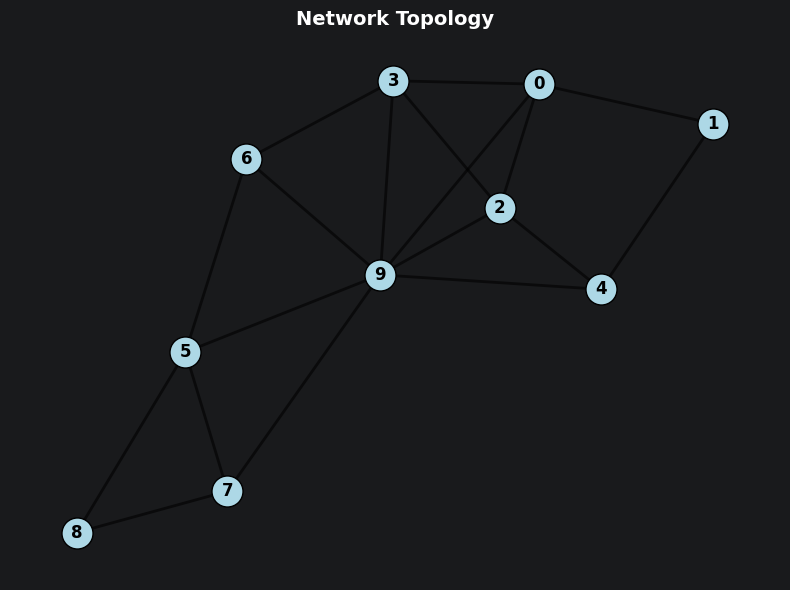

In [41]:

random_graph = NetworkTopology.random_graph(len(agent_list))

NetworkTopology.visualize_graph(random_graph)

In [3]:

def Consensus_step_fully_connected_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.fully_connected_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_cycle_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.cycle_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_star_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):
    graph = NetworkTopology.star_graph(len(agent_list))
    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

def Consensus_step_random_graph(agent_list, graph, k, epoch, num_epochs,comm_cost=None):

    Average_consensus_algorithm(agent_list, graph, comm_cost=comm_cost)

# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {
    f"AC_fully_connected_graph" : Consensus_step_fully_connected_graph,
    f"AC_cycle_graph)"          : Consensus_step_cycle_graph,
    f"AC_star_graph"            : Consensus_step_star_graph,
    f"AC_random_graph"          : Consensus_step_random_graph
}

results,comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)



  RUN — méthode : AC_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/60] threads started …
Agent 3 start
Agent 4 start
Agent 5 start
Agent 2 start
Agent 9 start
Agent 8 start
Agent 6 start
Agent 0 start
Agent 1 start
Agent 7 start
Model3 - Acc:11.06 % - Loss:2.3013681674003603 %
Model4 - Acc:9.82 % - Loss:2.303698257923126 %
Model5 - Acc:11.3 % - Loss:2.3013923263549803 %
Model2 - Acc:10.58 % - Loss:2.302952967643738 %
Model9 - Acc:10.82 % - Loss:2.299440689563751 %
Model8 - Acc:11.96 % - Loss:2.30008101940155 %
Model6 - Acc:12.32 % - Loss:2.300646574497223 %
Model1 - Acc:10.22 % - Loss:2.302751025676727 %
Model0 - Acc:10.68 % - Loss:2.3036297640800476 %
Model7 - Acc:10.38 % - Loss:2.301808189868927 %
[DEBUG] set_epoch_messages called → 90 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 90
[DEBUG] _record epoch=0 → n_messages=90
  [Epoch 1/60] ✓  time=35.95s  cumulative=35.95s
  [Epoch 2/

In [4]:
comparator.rank()


══════════════════════════════════════════════════════════════════════
  CLASSEMENT DES MÉTHODES PAR EFFICACITÉ (accuracy / MB)
──────────────────────────────────────────────────────────────────────
  Rang  Méthode                   Total MB     Synchro moy    Efficacité
──────────────────────────────────────────────────────────────────────
  1     AC_fully_connected_graph  1277.284     23.14          N/A
  2     AC_cycle_graph)           283.841      11.44          N/A
  3     AC_star_graph             255.457      10.53          N/A
  4     AC_random_graph           571.939      14.72          N/A
══════════════════════════════════════════════════════════════════════



[('AC_fully_connected_graph', 1277.2842407226562, 23.143676668405533, 0.0),
 ('AC_cycle_graph)', 283.8409423828125, 11.43574498128146, 0.0),
 ('AC_star_graph', 255.45684814453125, 10.528798319865018, 0.0),
 ('AC_random_graph', 571.9394989013672, 14.718178325953582, 0.0)]

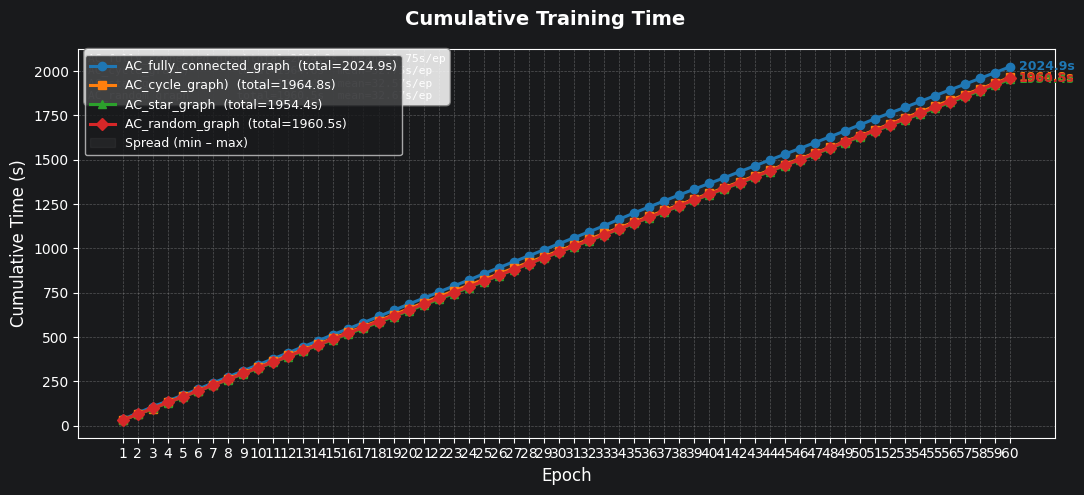

In [5]:
plot_cumulative_times(results)

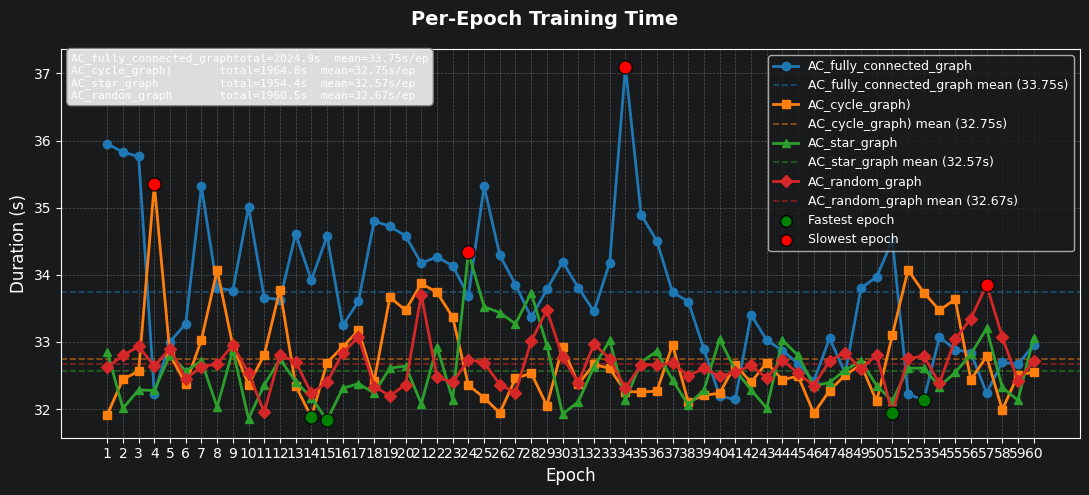

In [6]:
plot_epoch_times(results)

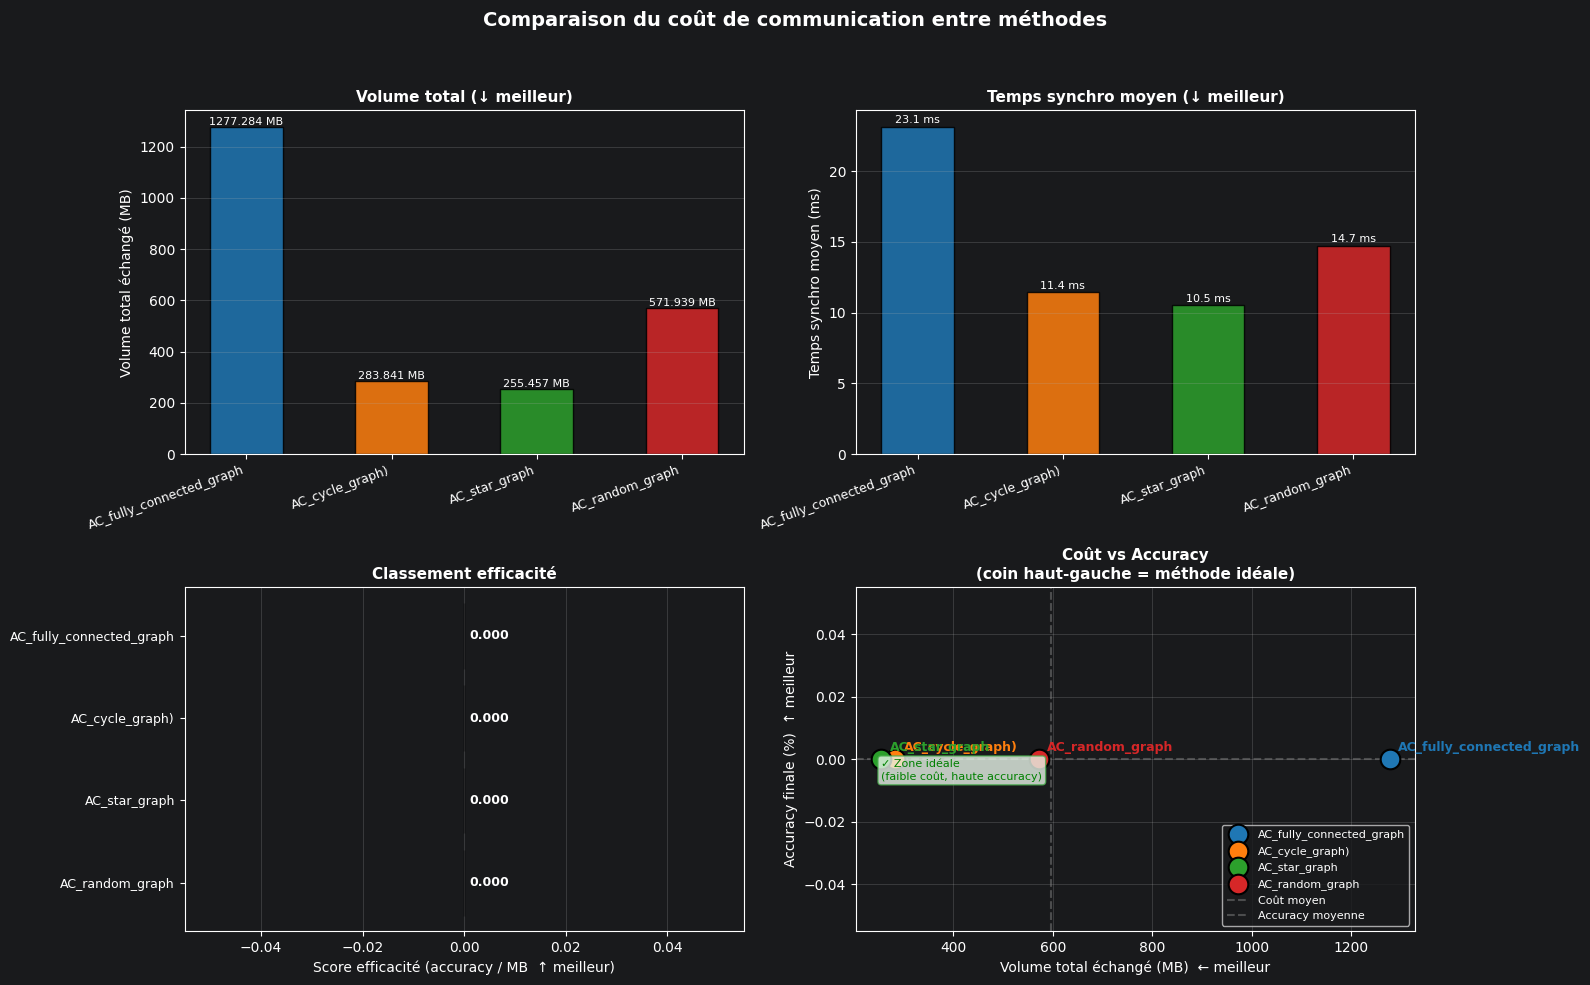

In [7]:
comparator.plot_comparison()

In [8]:
for result in results:
    print(f"\n── {result.method_name} ──")
    result.comm_cost.summary()


── AC_fully_connected_graph ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 1277.284 MB
    Total messages    : 5,400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 23.14 ms
    Synchro totale    : 1388.6 ms
──────────────────────────────────────────────────────────
  EFFICACITÉ
    Accuracy finale   : N/A
    Score efficacité  : N/A
    Coût/point acc.   : N/A
══════════════════════════════════════════════════════════


── AC_cycle_graph) ──

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_cycle_graph)
──────────────────────────────────────────────────────────
  Agents

In [9]:
print_benchmark_summary(results)


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected_graph           1.3637     49.81%     48.80%
AC_cycle_graph)                    1.2381     56.03%     58.60%
AC_star_graph                      1.1137     60.69%     68.98%
AC_random_graph                    1.2763     54.51%     53.02%


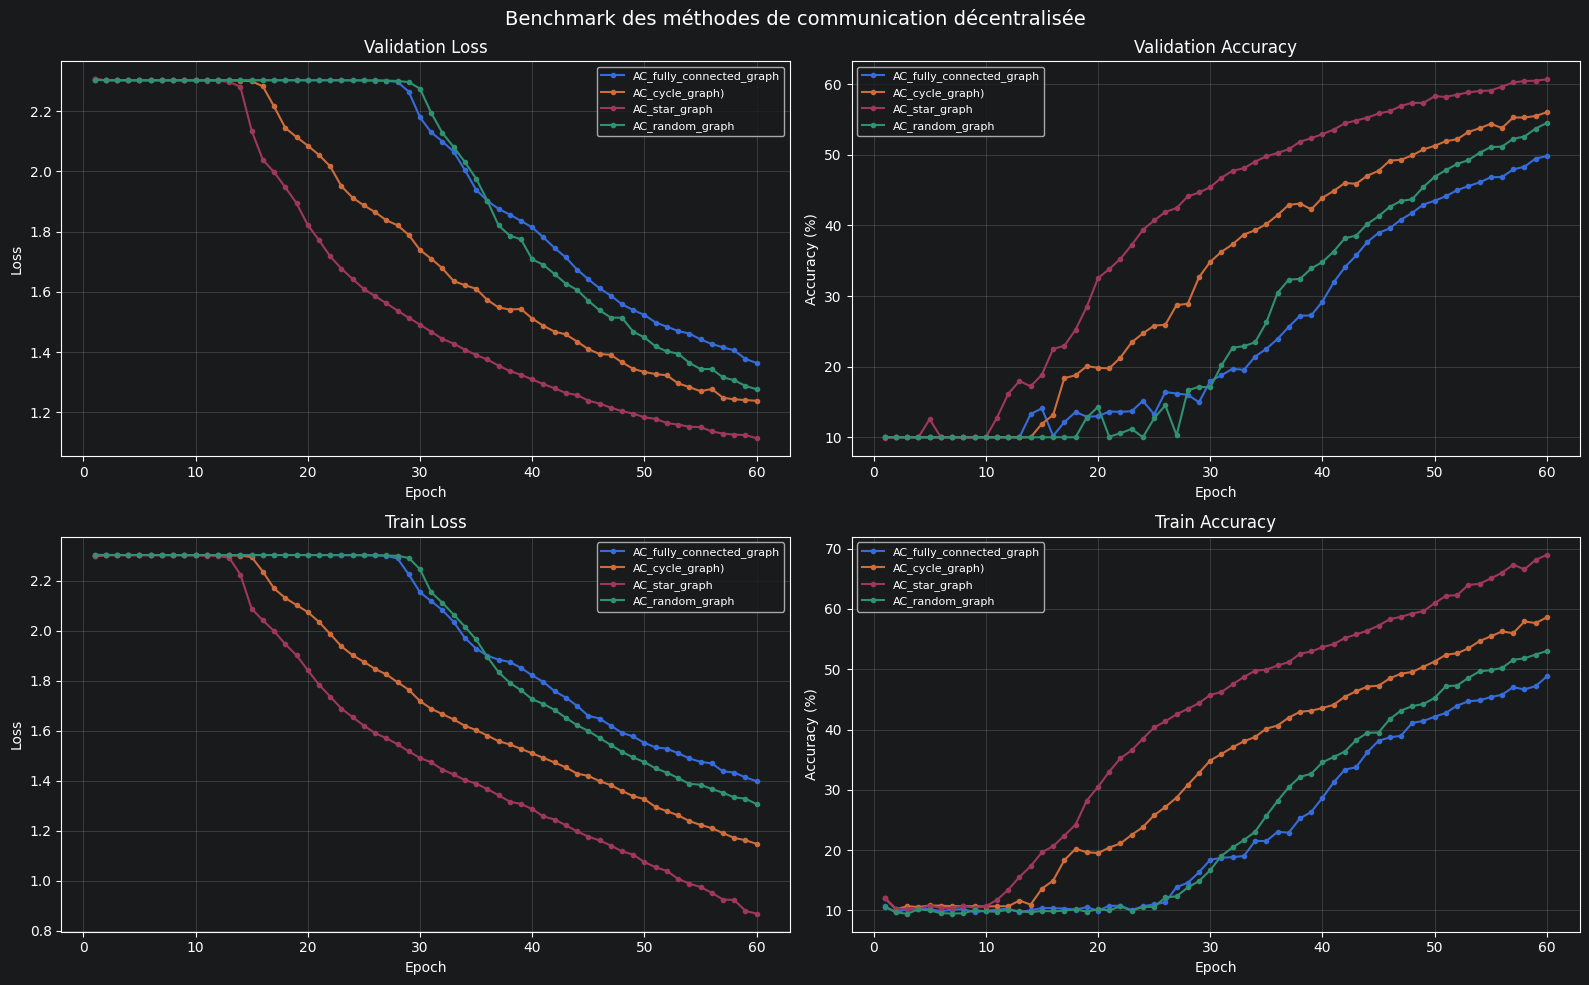

In [10]:
plot_all_benchmark_metrics(results)

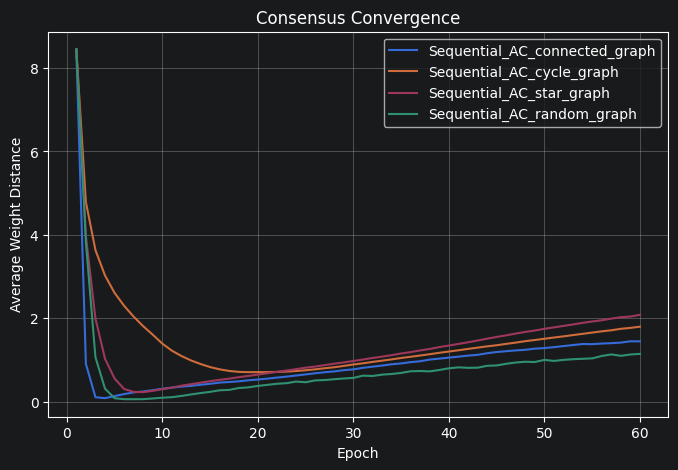

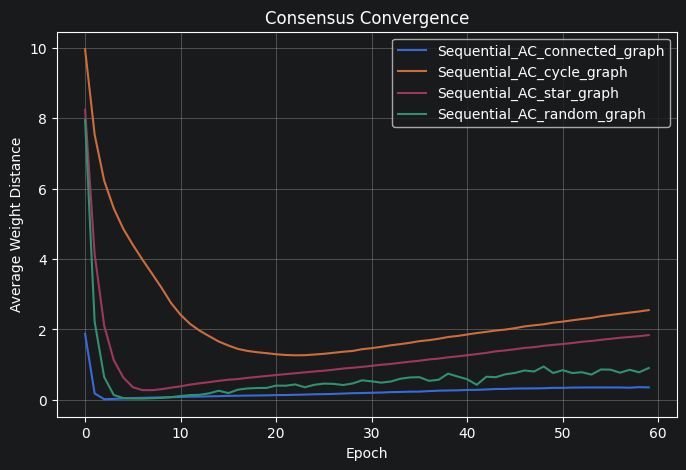

In [50]:
plot_average_distance(results)

import metrics as me
me.metrics.plot_average_distance(results)


═══════════════════════════════════════════════════════
  RunResult : AC_fully_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 49.81%
  Val Loss  finale : 1.3637
  Temps total      : 2024.86s
  Temps moyen/ép.  : 33.75s
  Époque la + rapide : ép.53 (32.13s)
  Époque la + lente  : ép.34 (37.10s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 1277.284 MB
    Total messages    : 5,400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 23.14 ms
    Synchro totale    : 1388.6 ms
────────────────────────────────────────────

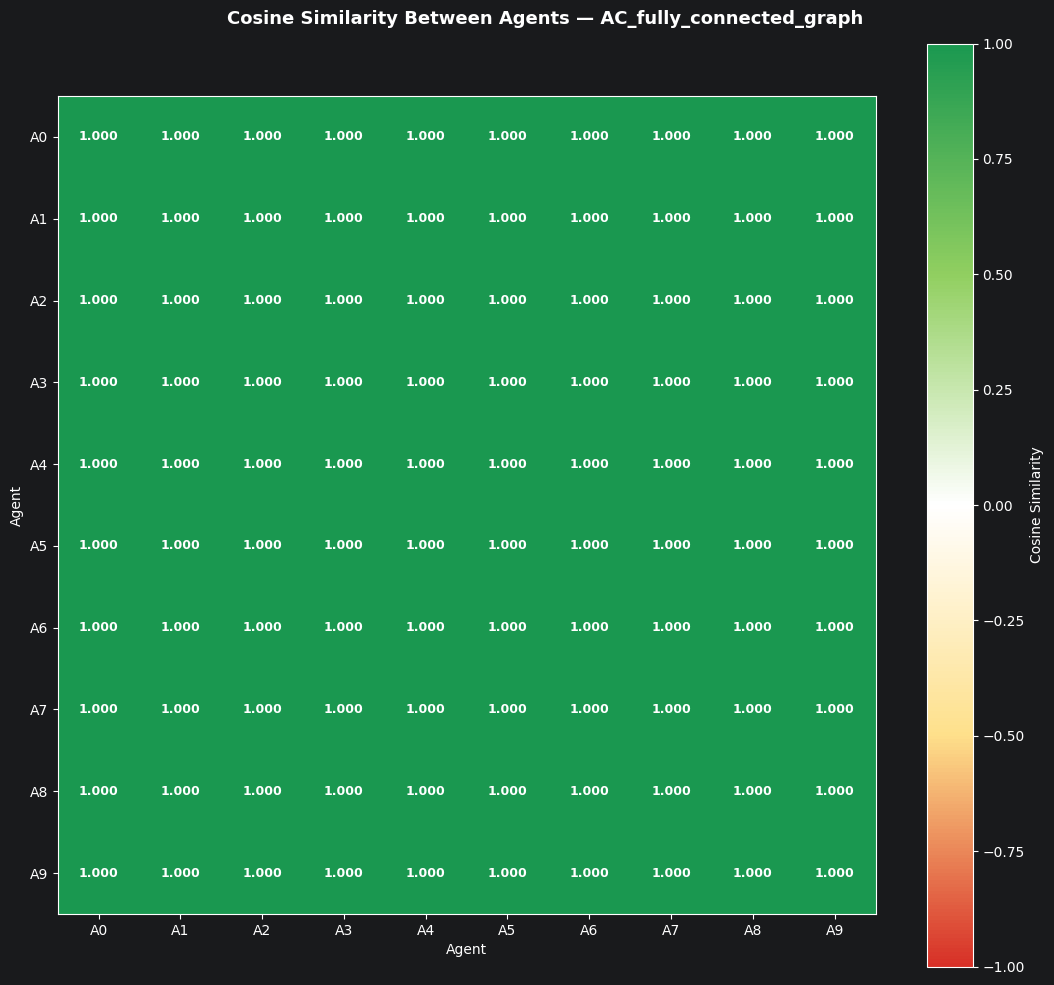

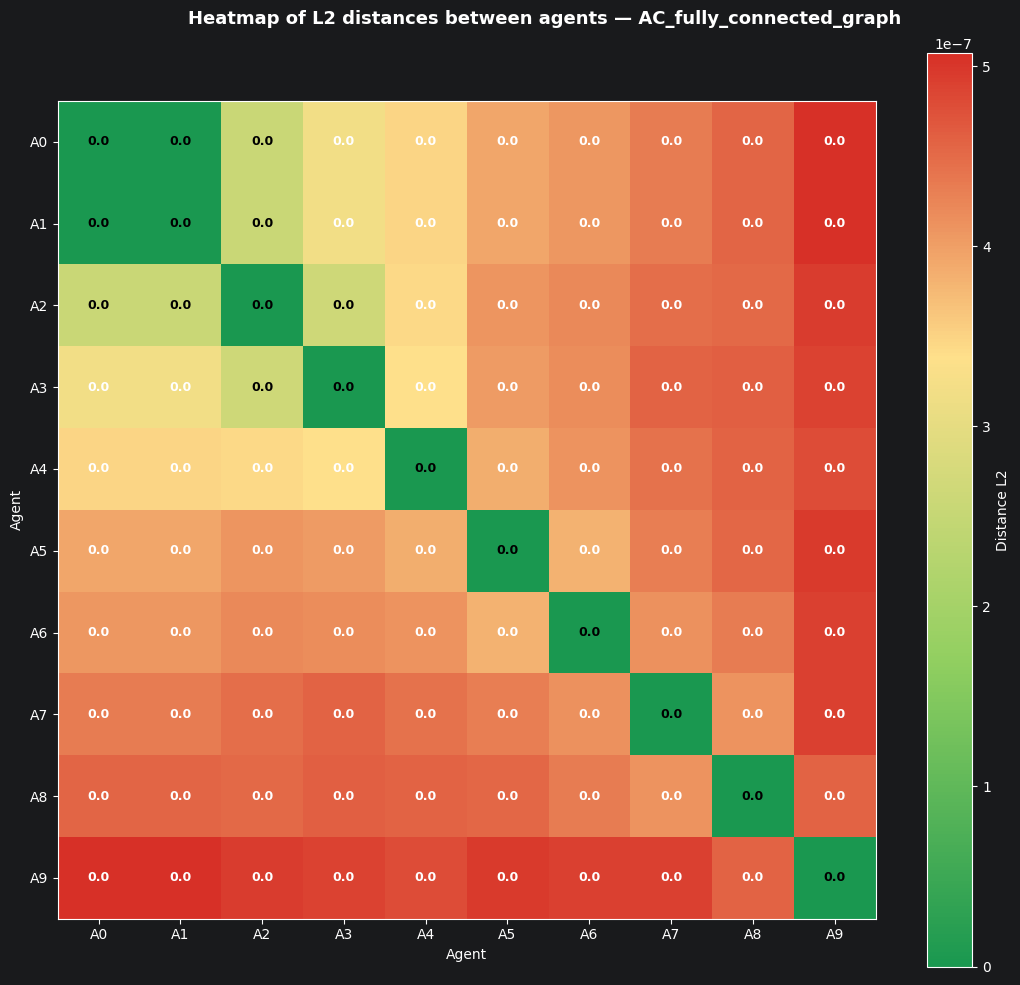

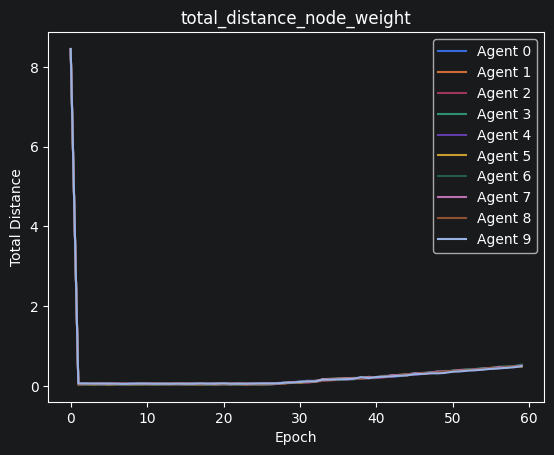

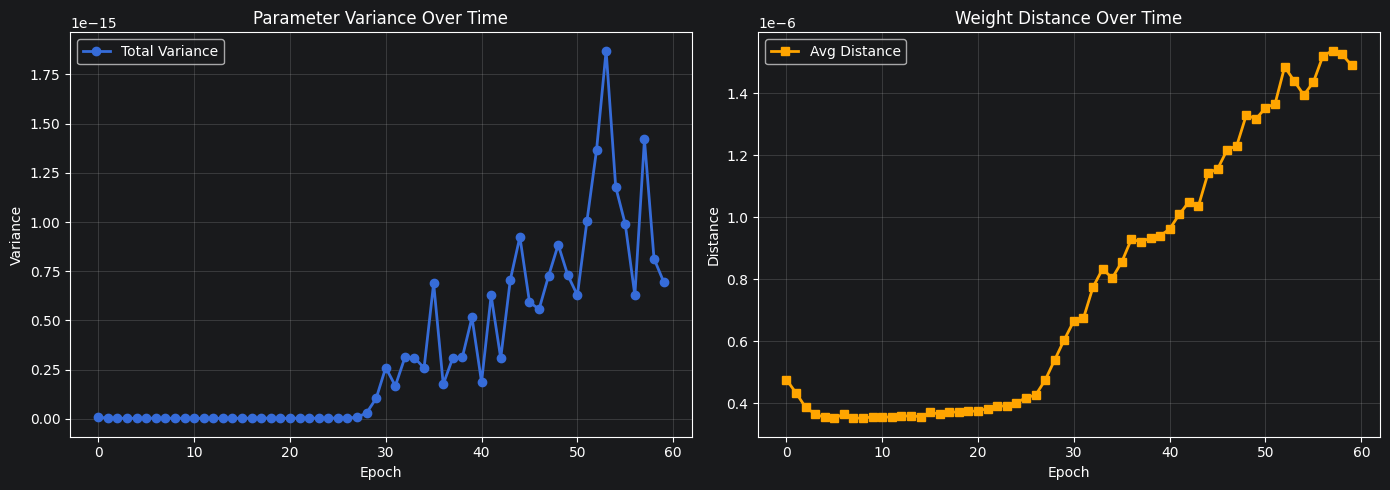


═══════════════════════════════════════════════════════
  RunResult : AC_cycle_graph)
───────────────────────────────────────────────────────
  Accuracy  finale : 56.03%
  Val Loss  finale : 1.2381
  Temps total      : 1964.79s
  Temps moyen/ép.  : 32.75s
  Époque la + rapide : ép.14 (31.88s)
  Époque la + lente  : ép.4 (35.35s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_cycle_graph)
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 283.841 MB
    Total messages    : 1,200
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 11.44 ms
    Synchro totale    : 686.1 ms
──────────────────────────────────────────────────────────
  EFFI

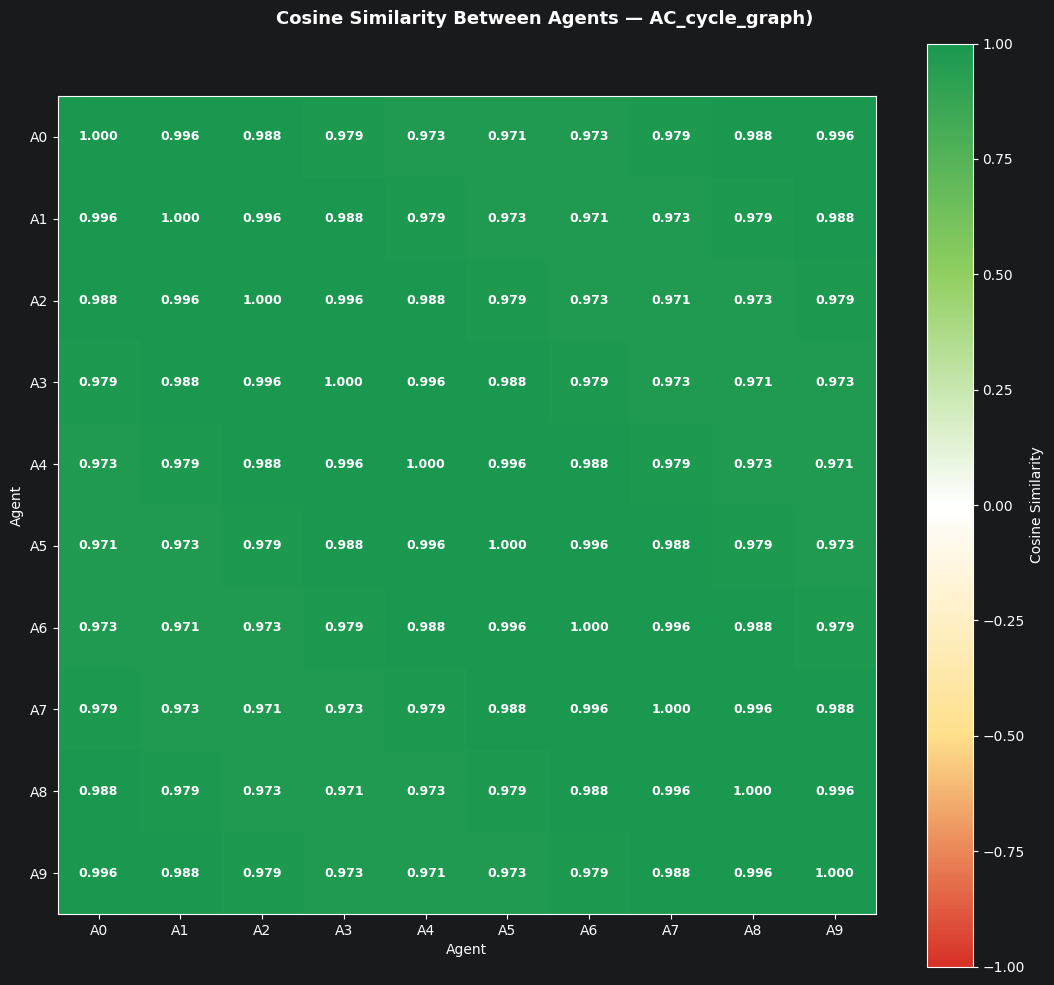

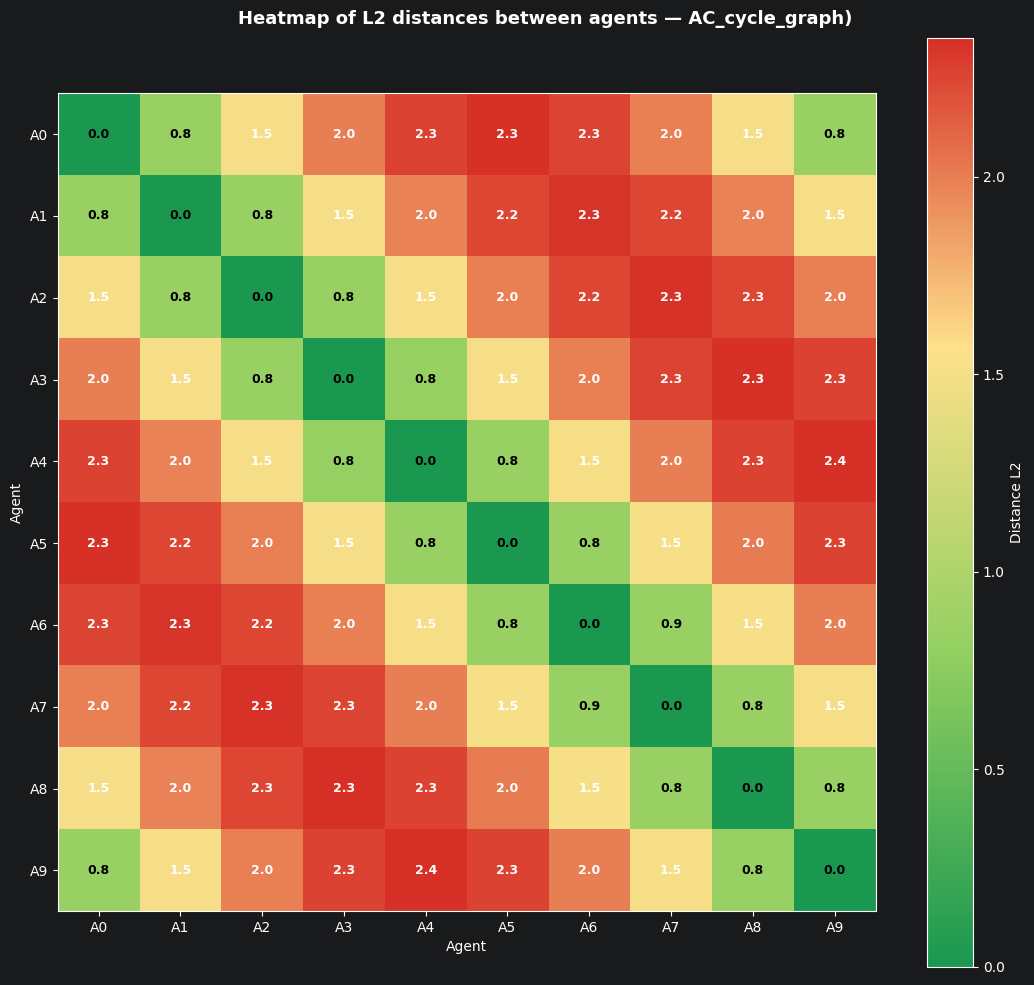

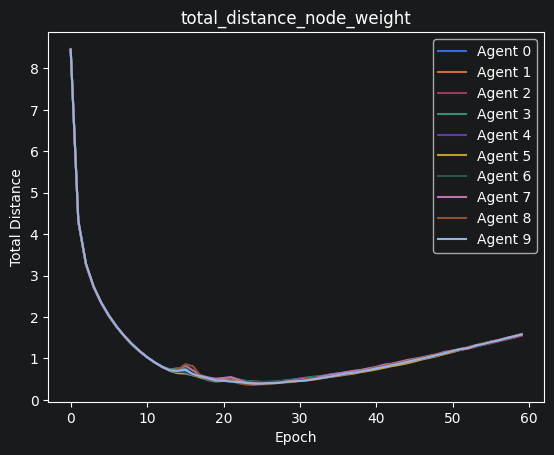

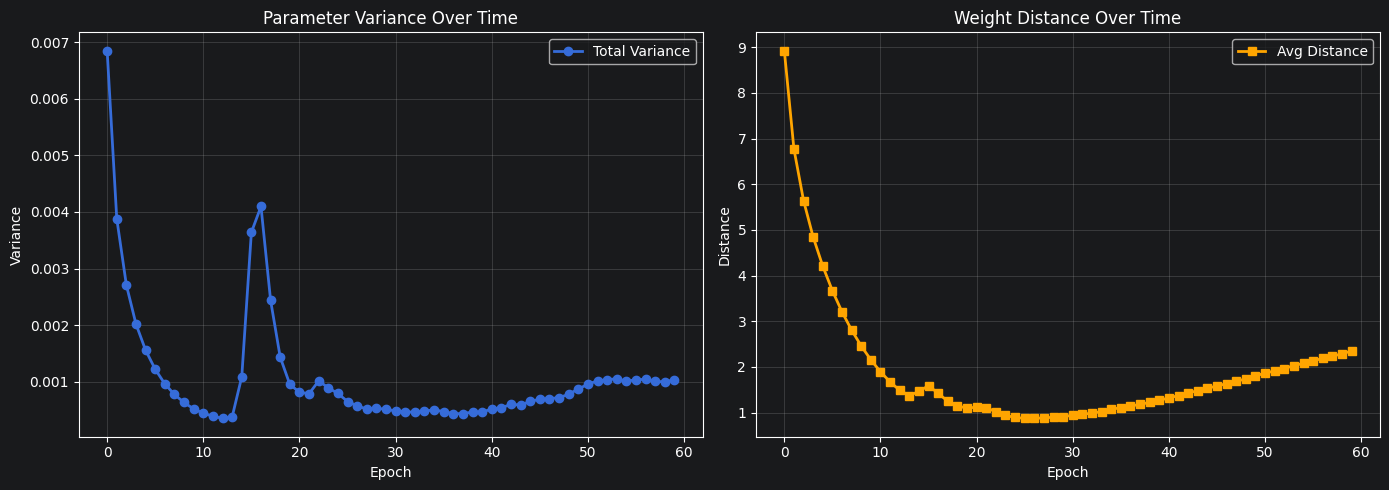


═══════════════════════════════════════════════════════
  RunResult : AC_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 60.69%
  Val Loss  finale : 1.1137
  Temps total      : 1954.39s
  Temps moyen/ép.  : 32.57s
  Époque la + rapide : ép.15 (31.84s)
  Époque la + lente  : ép.24 (34.34s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_star_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 255.457 MB
    Total messages    : 1,080
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 10.53 ms
    Synchro totale    : 631.7 ms
──────────────────────────────────────────────────────────
  EFFICAC

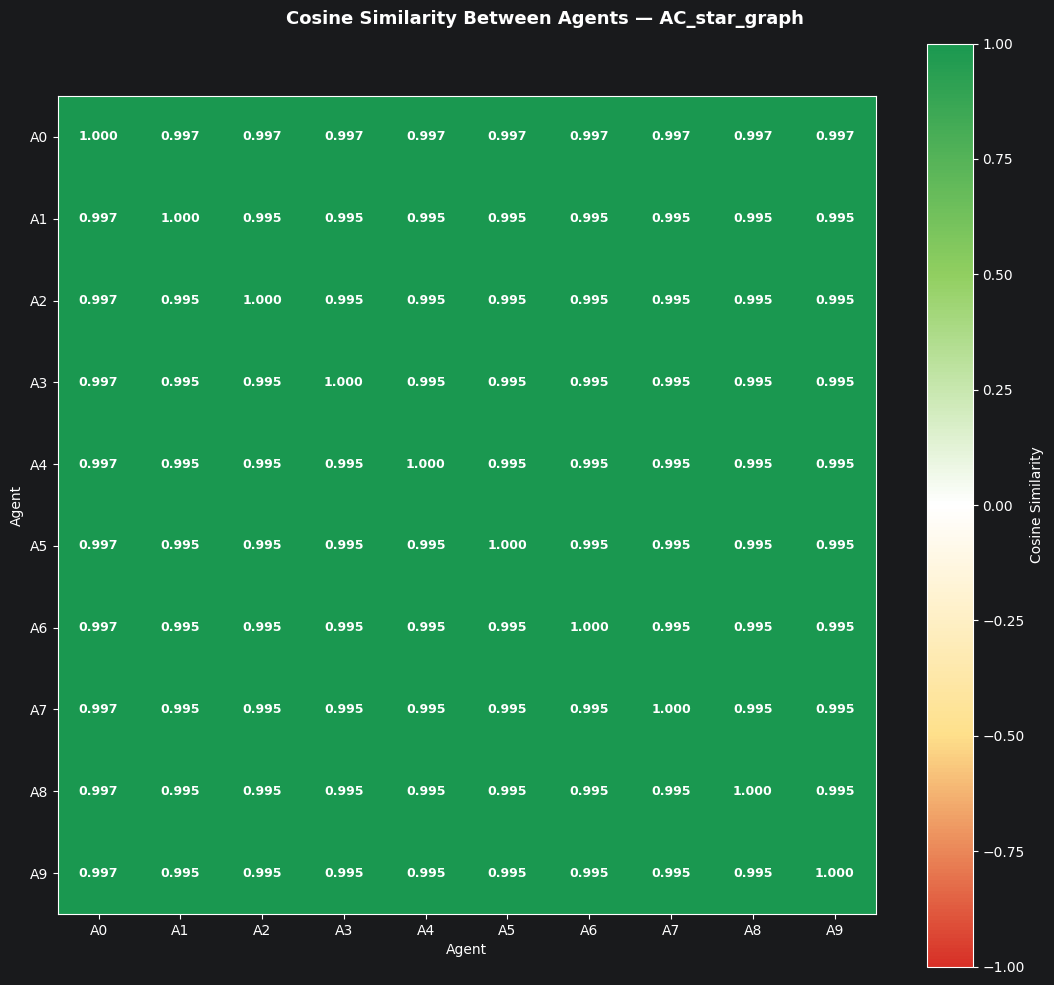

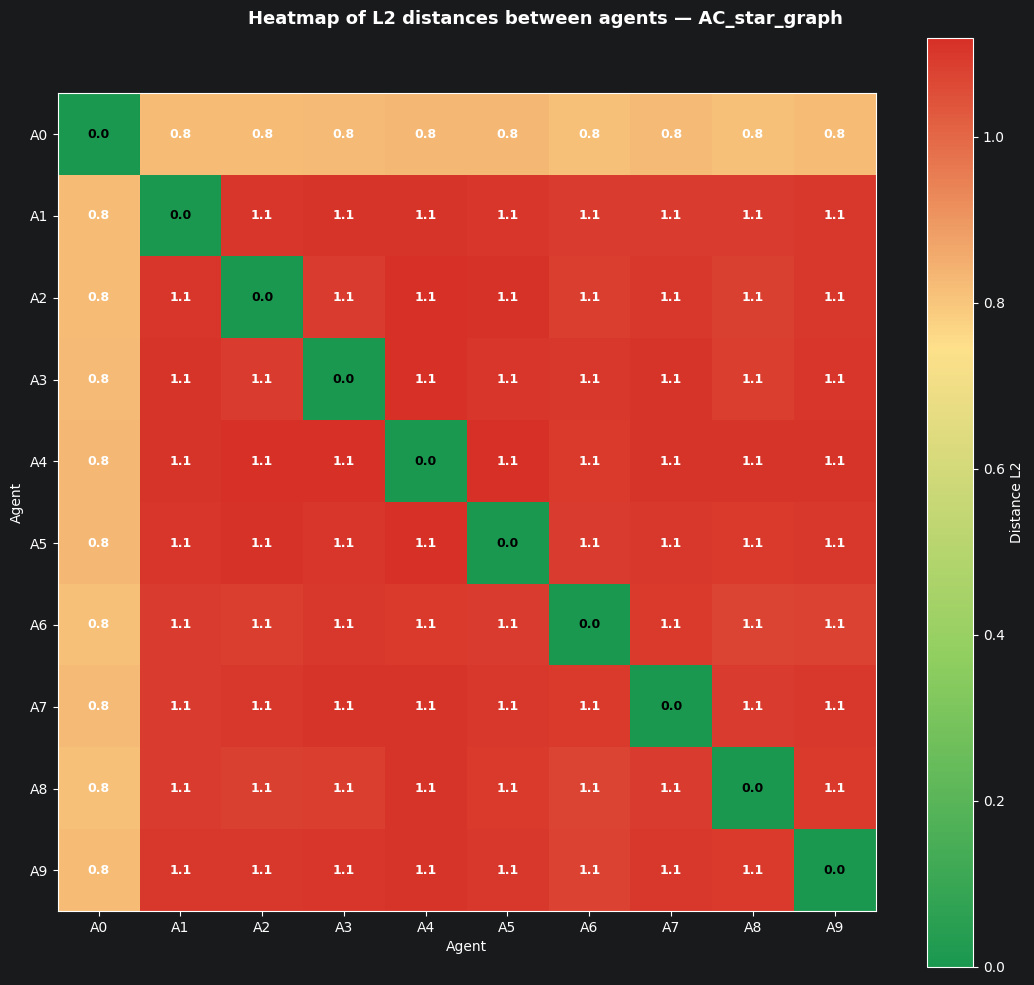

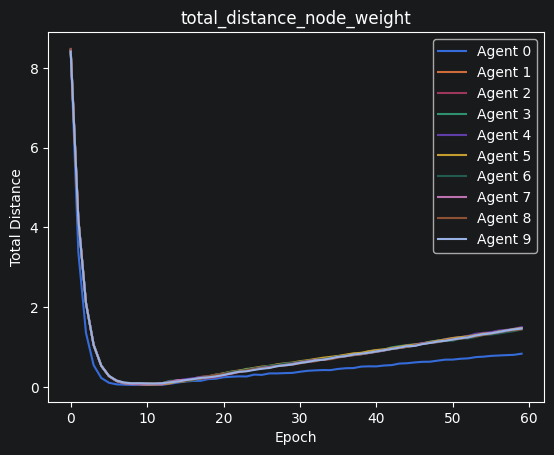

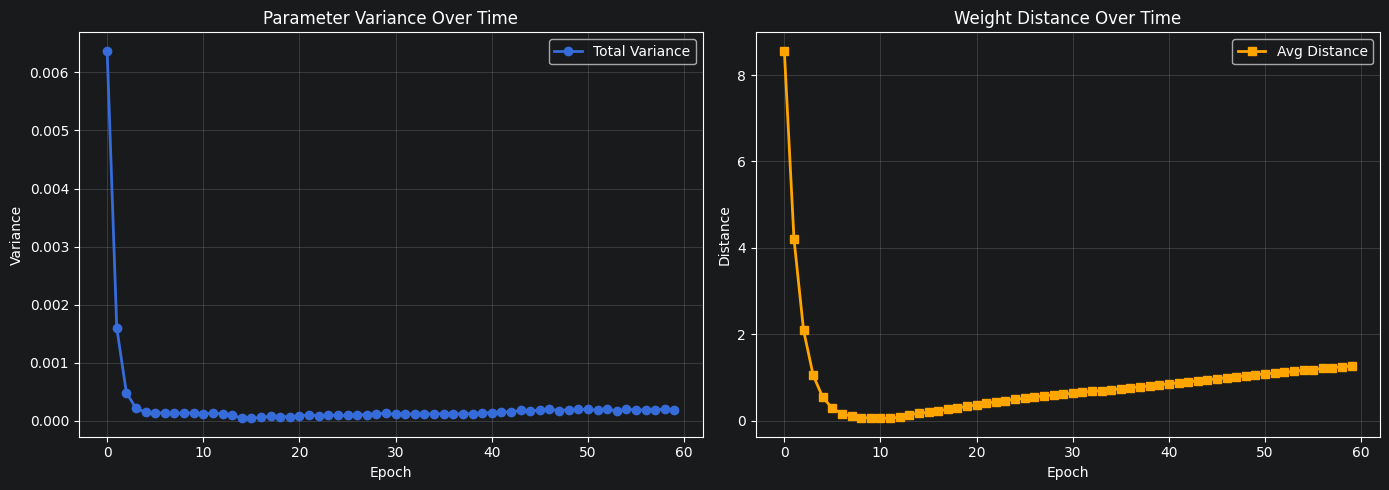


═══════════════════════════════════════════════════════
  RunResult : AC_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 54.51%
  Val Loss  finale : 1.2763
  Temps total      : 1960.45s
  Temps moyen/ép.  : 32.67s
  Époque la + rapide : ép.51 (31.94s)
  Époque la + lente  : ép.57 (33.85s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_random_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 571.939 MB
    Total messages    : 2,418
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 14.72 ms
    Synchro totale    : 883.1 ms
──────────────────────────────────────────────────────────
  EFF

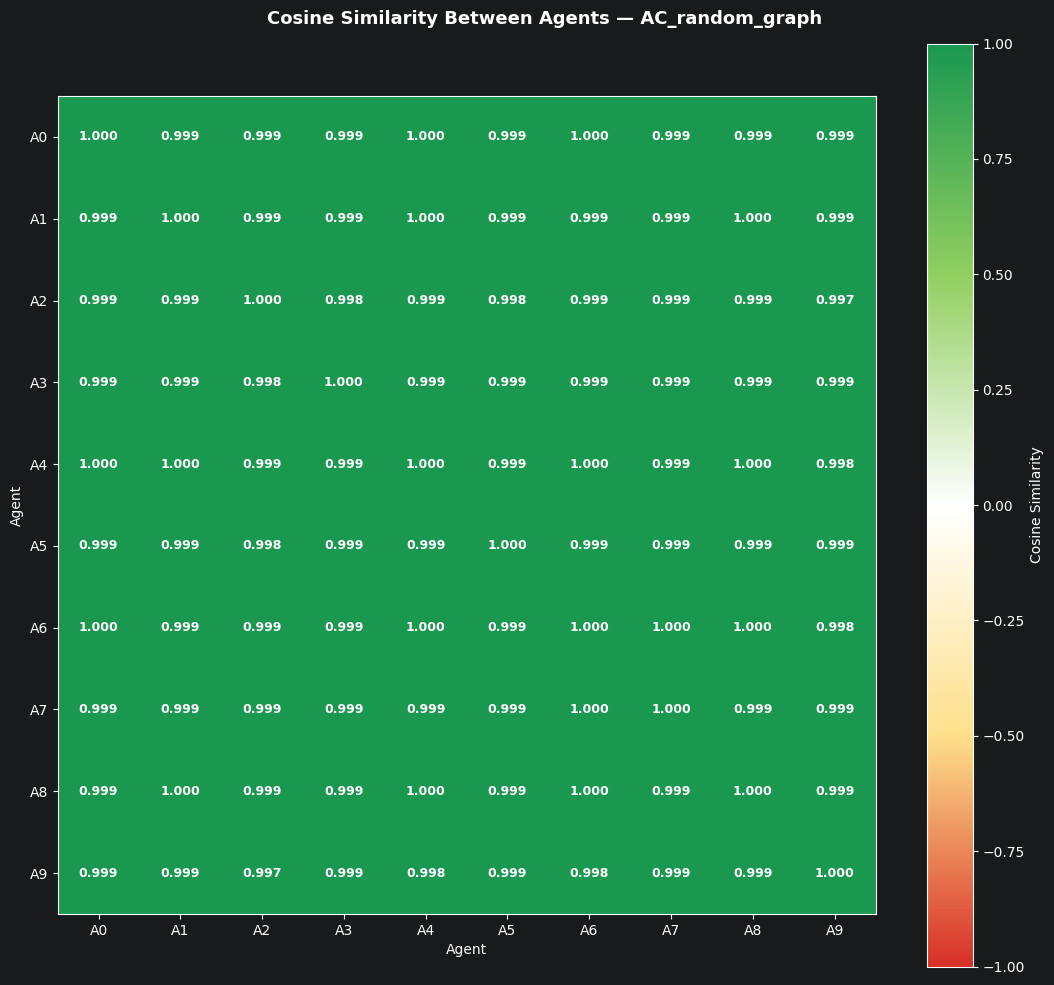

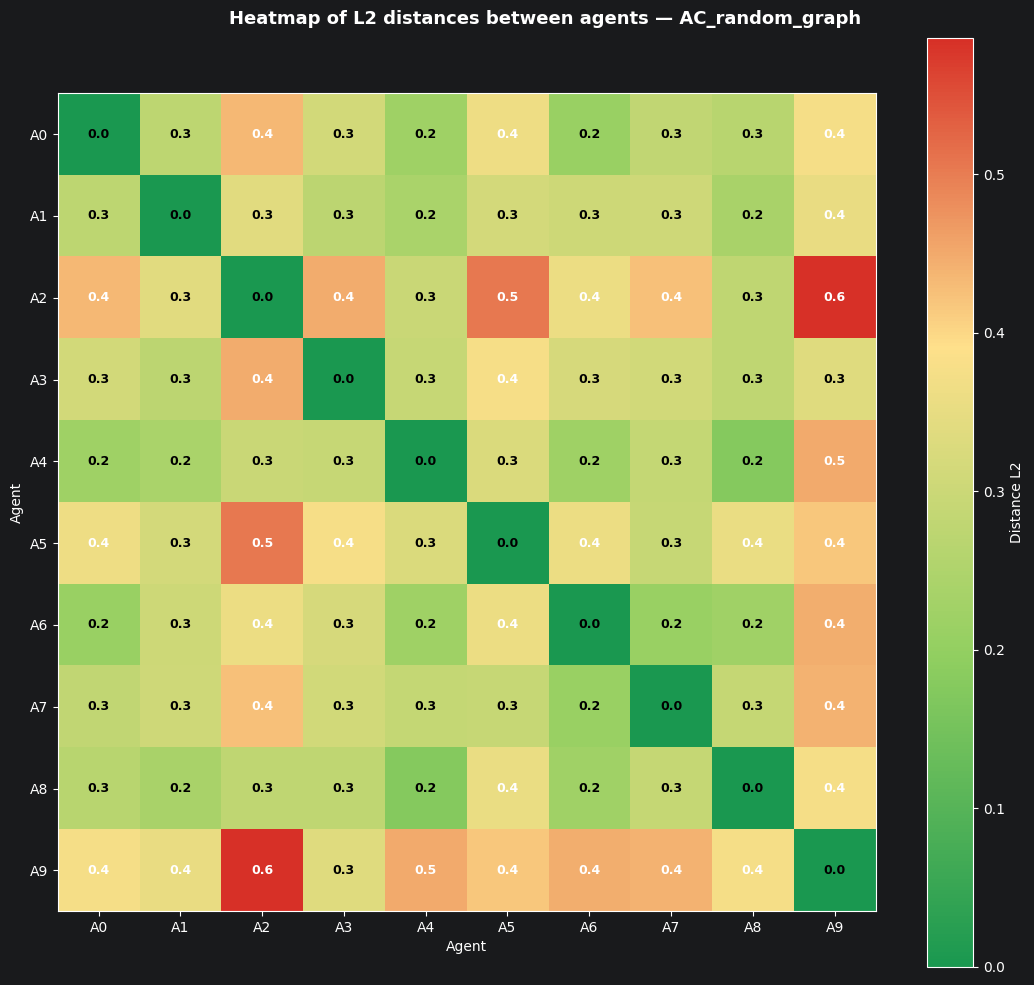

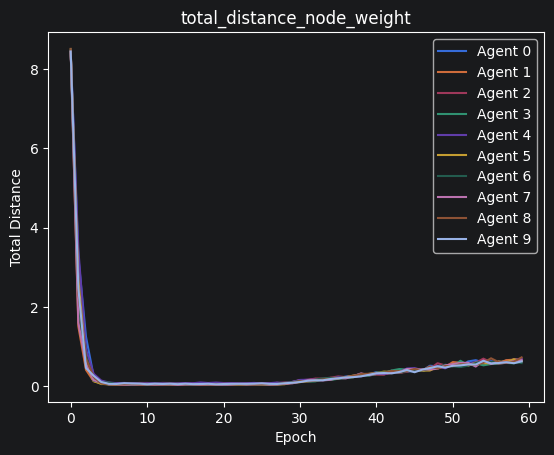

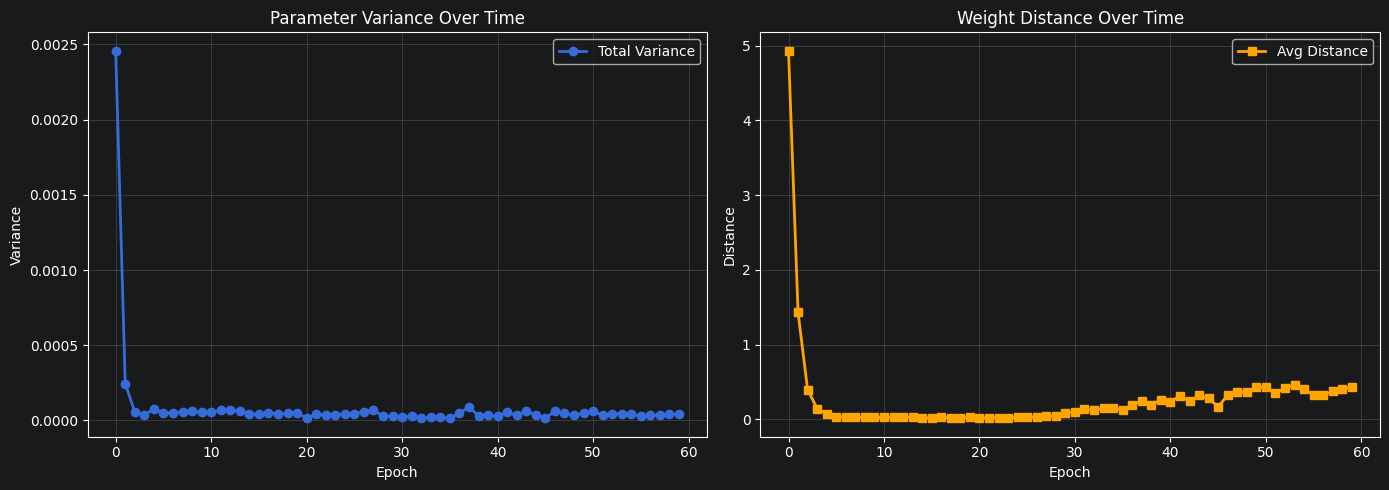

In [12]:
for result in results:
    print(result)
    result.comm_cost.summary()
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [13]:
def Average_consensus_fully_connected_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph_k(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph_k,

    "AC_cycle_graph":
        Average_consensus_cycle_graph_k,

    "AC_star_graph":
        Average_consensus_star_graph_k,

    "AC_random_graph":
        Average_consensus_random_graph_k,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550

  RUN — méthode : AC_fully_connected_graph
0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/60] threads started …
Agent 7 start
Agent 5 start
Agent 6 start
Agent 4 start
Agent 8 start
Agent 1 start
Agent 2 start
Agent 3 start
Agent 0 start
Agent 9 start
Model7 - Acc:9.84 % - Loss:2.3027203216552734 %
Model5 - Acc:12.02 % - Loss:2.3013041796684264 %
Model6 - Acc:9.7 % - Loss:2.3043356952667238 %
Model8 - Acc:10.44 % - Loss:2.297561724662781 %
Model1 - Acc:11.26 % - Loss:2.300276005268097 %
Model2 - Acc:10.68 % - Loss:2.301998558998108 %
Model4 - Acc:13.26 % - Loss:2.300024544239044 %
Model3 - Acc:9.88 % - Loss:2.301938171863556 %
Model0 - Acc:12.04 % - Loss:2.301575007915497 %
Model9 - Acc:12.3 % - Loss:2.3003169527053835 %
[DEBUG] set_epoch_messages called → 450 messages
    → avrg distance after iteration 1: 0.000000
   

In [14]:
comparator.rank()


══════════════════════════════════════════════════════════════════════
  CLASSEMENT DES MÉTHODES PAR EFFICACITÉ (accuracy / MB)
──────────────────────────────────────────────────────────────────────
  Rang  Méthode                   Total MB     Synchro moy    Efficacité
──────────────────────────────────────────────────────────────────────
  1     AC_fully_connected_graph  6386.421     212.23         N/A
  2     AC_cycle_graph            1419.205     168.48         N/A
  3     AC_star_graph             1277.284     165.48         N/A
  4     AC_random_graph           2772.180     182.51         N/A
══════════════════════════════════════════════════════════════════════



[('AC_fully_connected_graph', 6386.421203613281, 212.22511165154478, 0.0),
 ('AC_cycle_graph', 1419.2047119140625, 168.4761133394204, 0.0),
 ('AC_star_graph', 1277.2842407226562, 165.48475333644697, 0.0),
 ('AC_random_graph', 2772.1798706054688, 182.50920167580867, 0.0)]

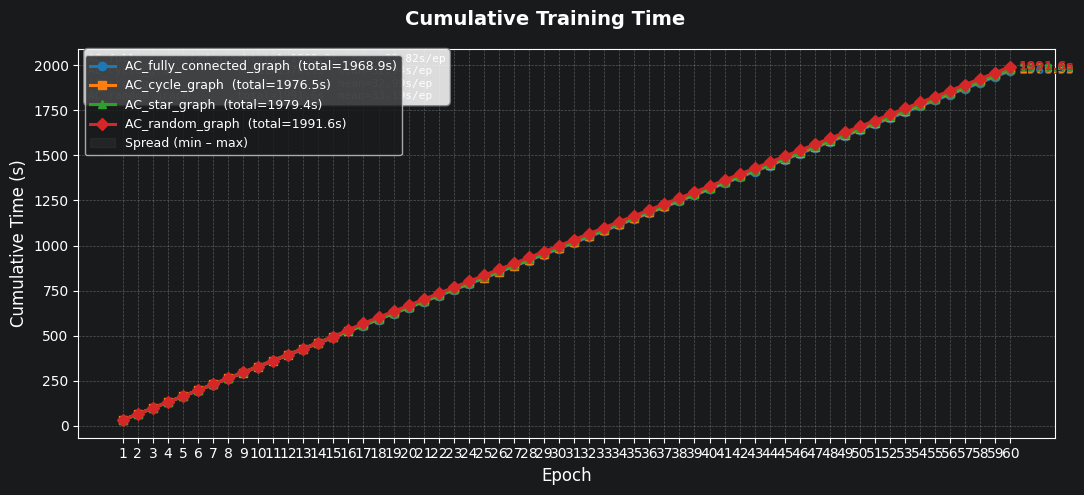

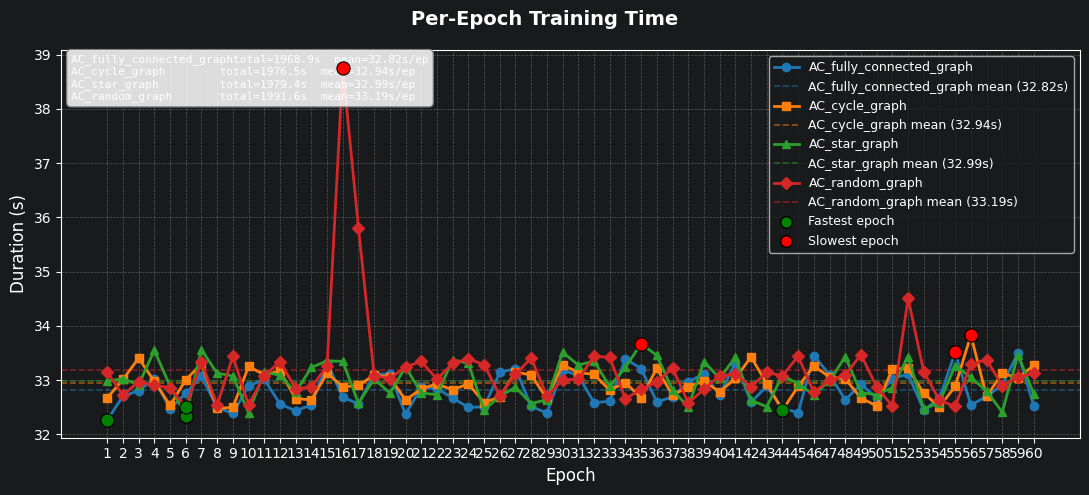

In [15]:
plot_cumulative_times(results)
plot_epoch_times(results)

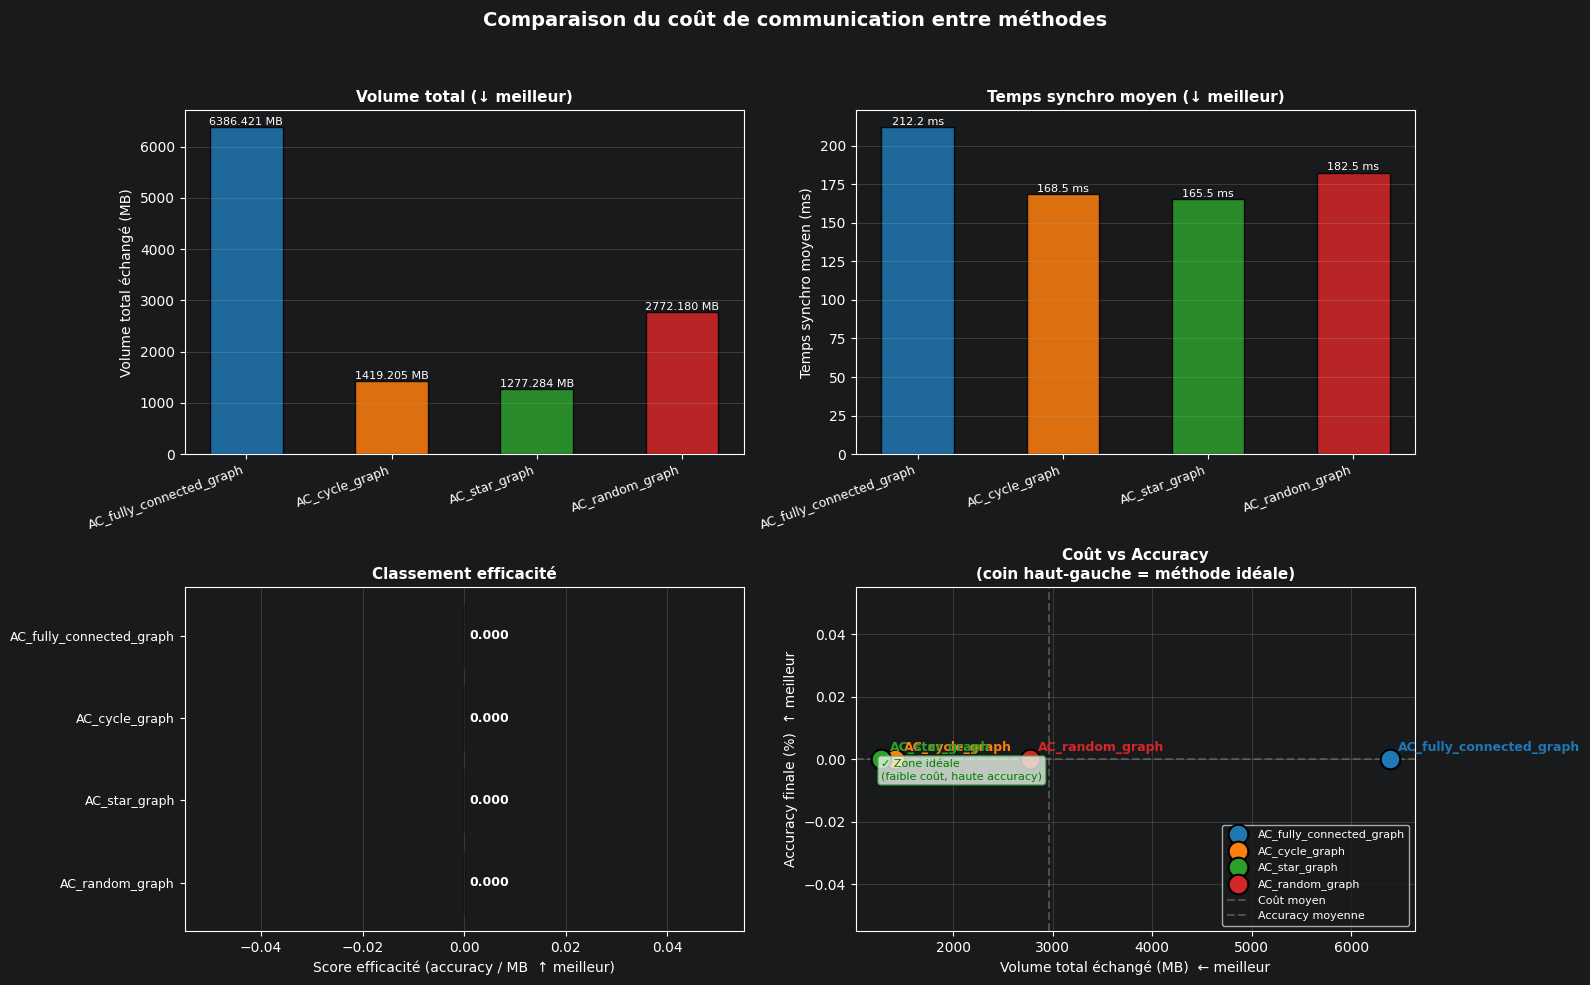

In [16]:
comparator.plot_comparison()

In [17]:
print_benchmark_summary(results)


Méthode                          Val Loss    Val Acc  Train Acc
AC_fully_connected_graph           1.3270     51.64%     51.46%
AC_cycle_graph                     1.4954     44.57%     43.22%
AC_star_graph                      1.2288     55.11%     58.20%
AC_random_graph                    2.3025     12.00%     10.60%


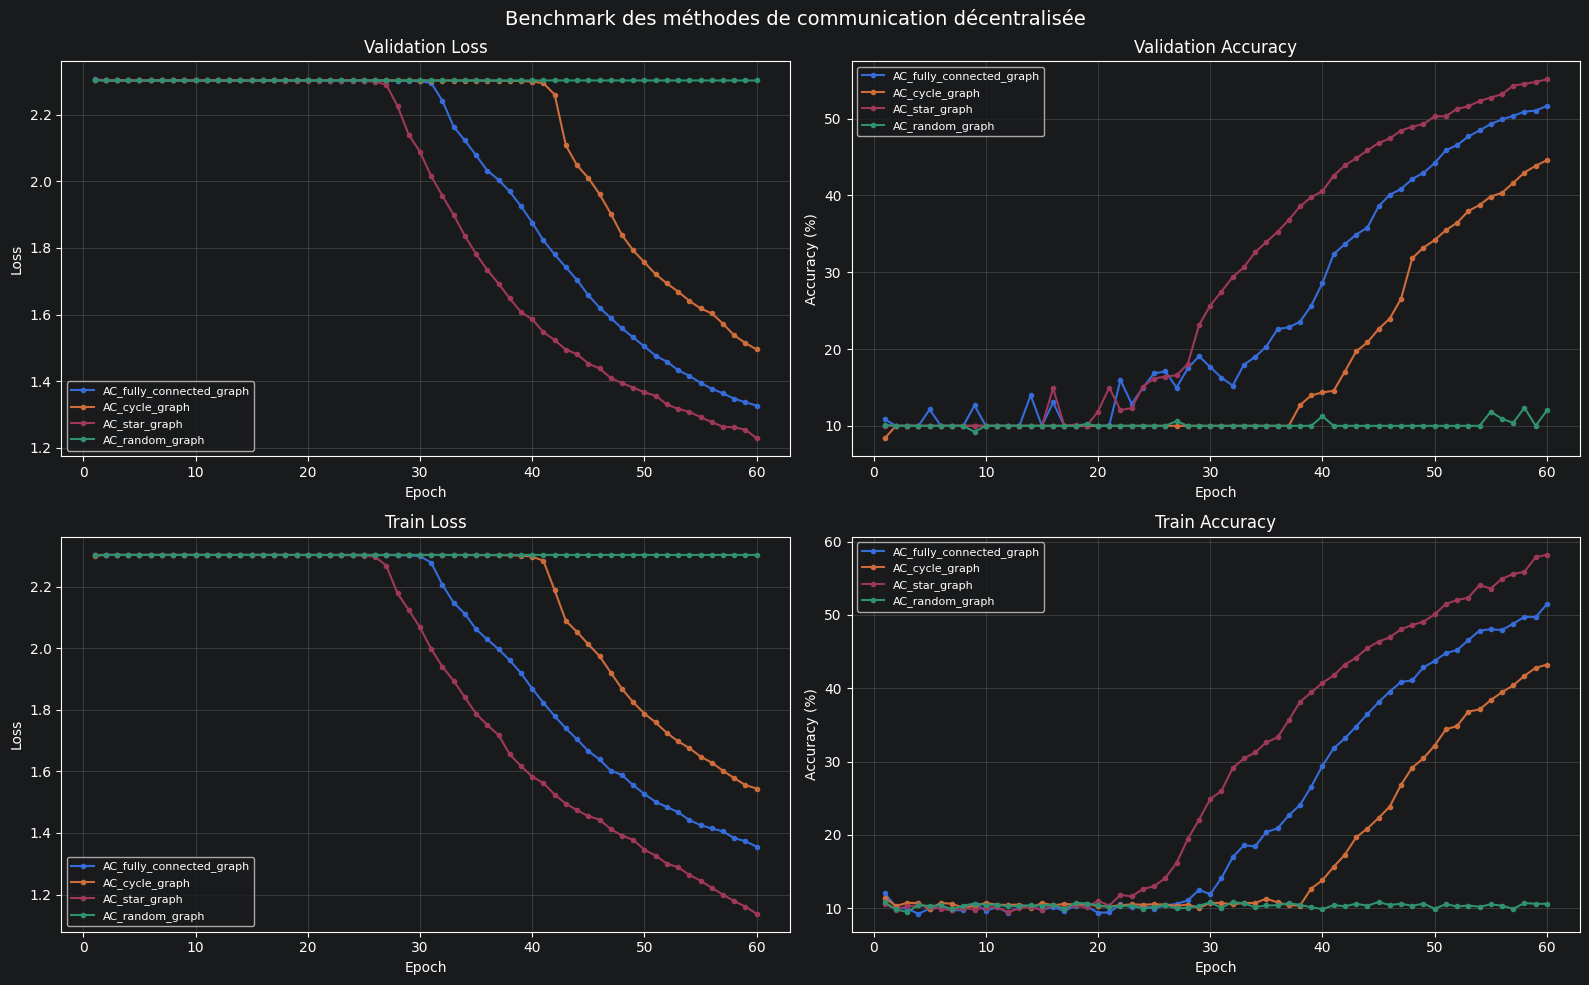

In [18]:
plot_all_benchmark_metrics(results)

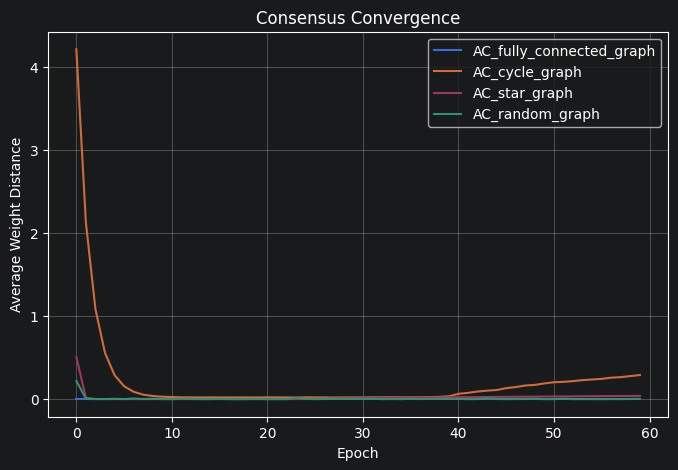

In [19]:
plot_average_distance(results)


── AC_fully_connected_graph ──

═══════════════════════════════════════════════════════
  RunResult : AC_fully_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 51.64%
  Val Loss  finale : 1.3270
  Temps total      : 1968.92s
  Temps moyen/ép.  : 32.82s
  Époque la + rapide : ép.1 (32.27s)
  Époque la + lente  : ép.55 (33.51s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_fully_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 6386.421 MB
    Total messages    : 27,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 212.23 ms
    Synchro totale    : 12733.5 ms
──────────

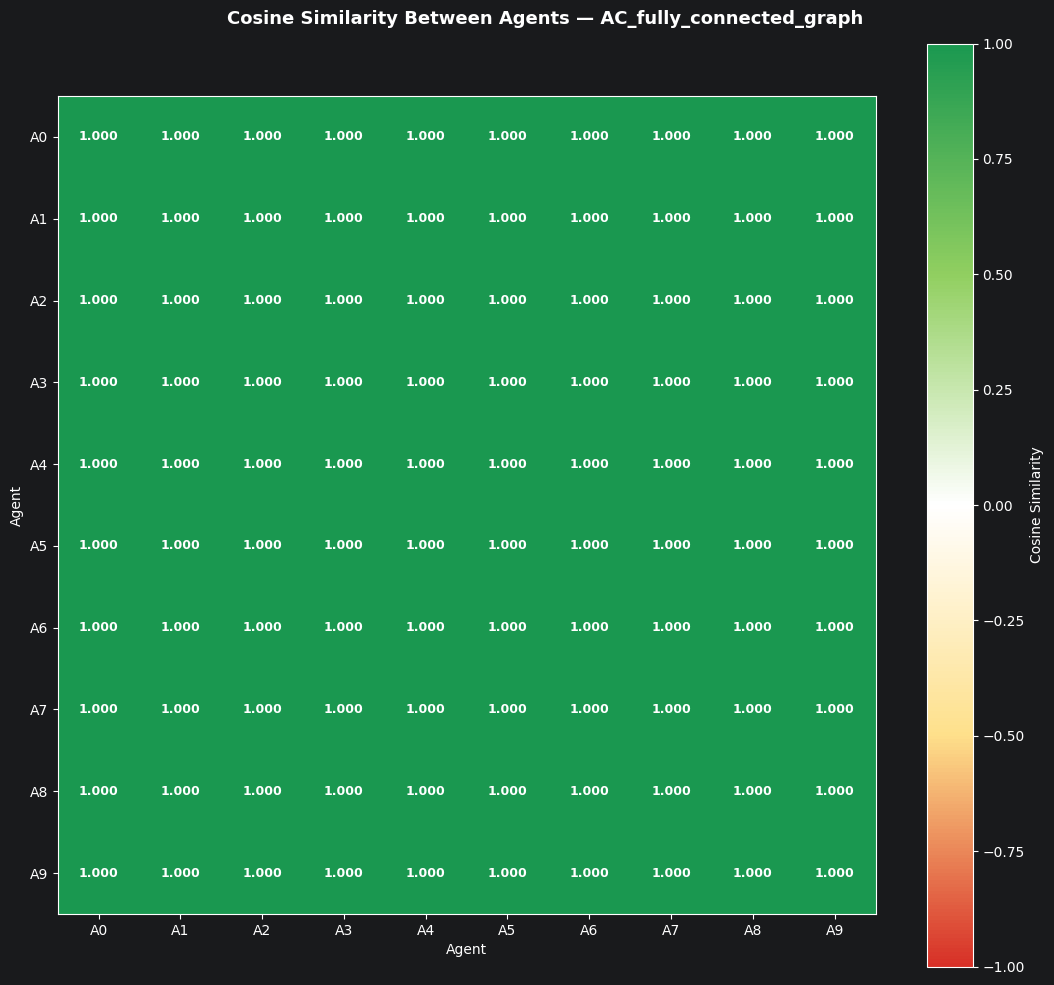

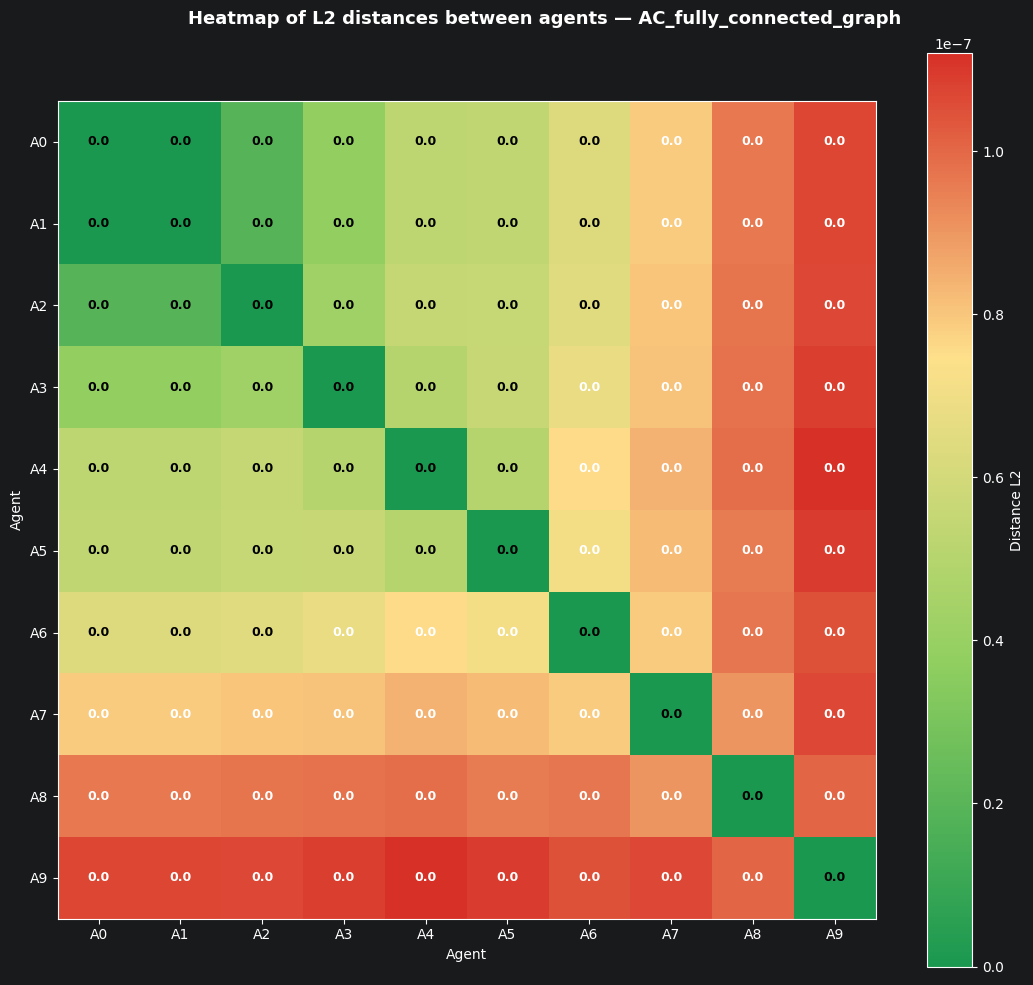

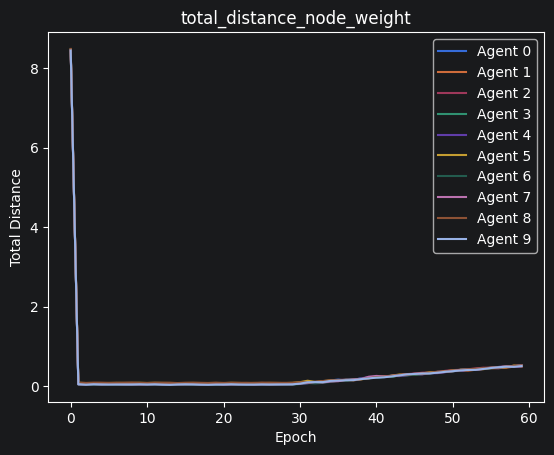

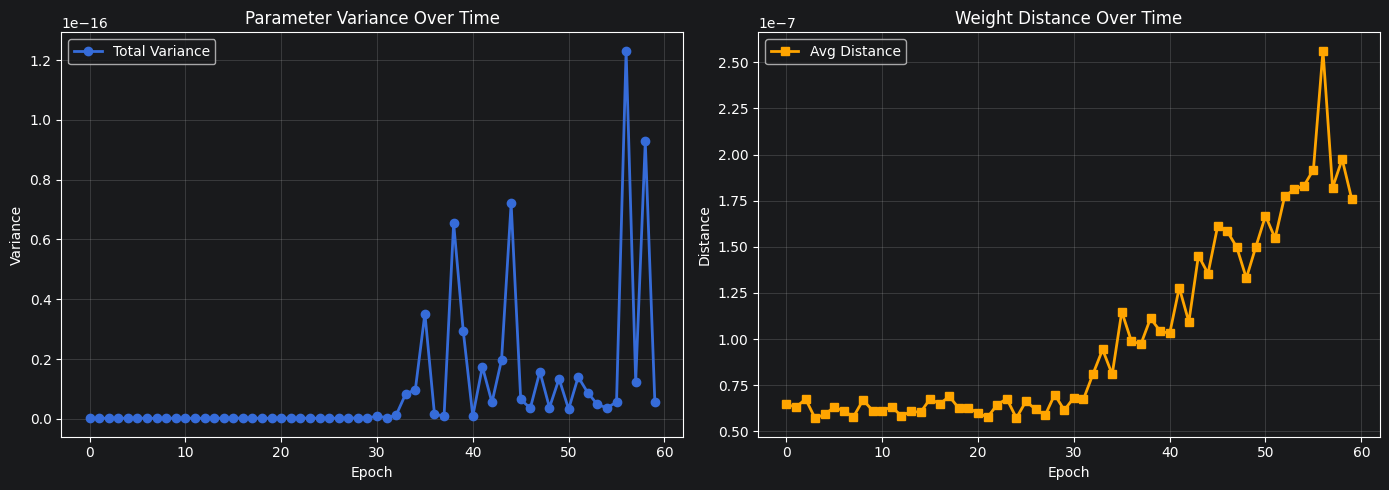


── AC_cycle_graph ──

═══════════════════════════════════════════════════════
  RunResult : AC_cycle_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 44.57%
  Val Loss  finale : 1.4954
  Temps total      : 1976.53s
  Temps moyen/ép.  : 32.94s
  Époque la + rapide : ép.44 (32.45s)
  Époque la + lente  : ép.56 (33.83s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_cycle_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 1419.205 MB
    Total messages    : 6,000
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 168.48 ms
    Synchro totale    : 10108.6 ms
────────────────────────────────────────

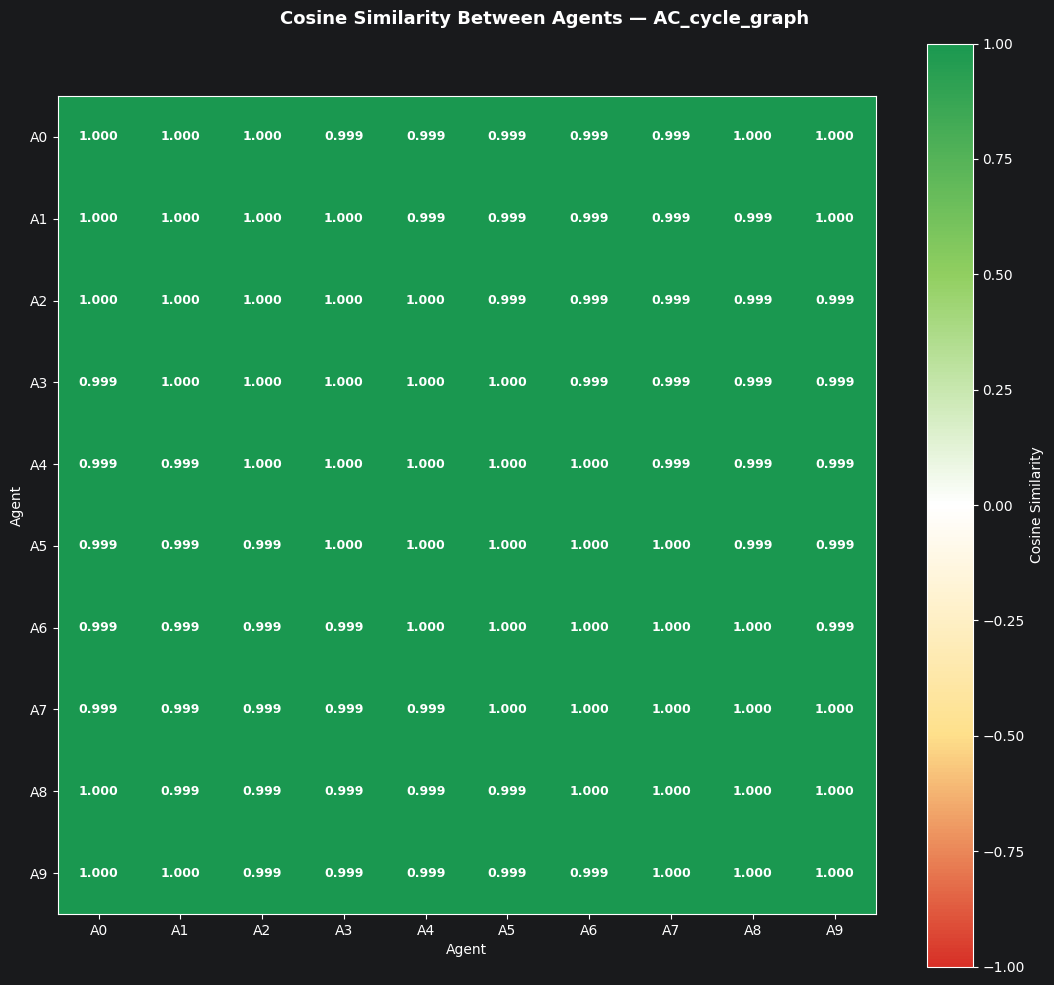

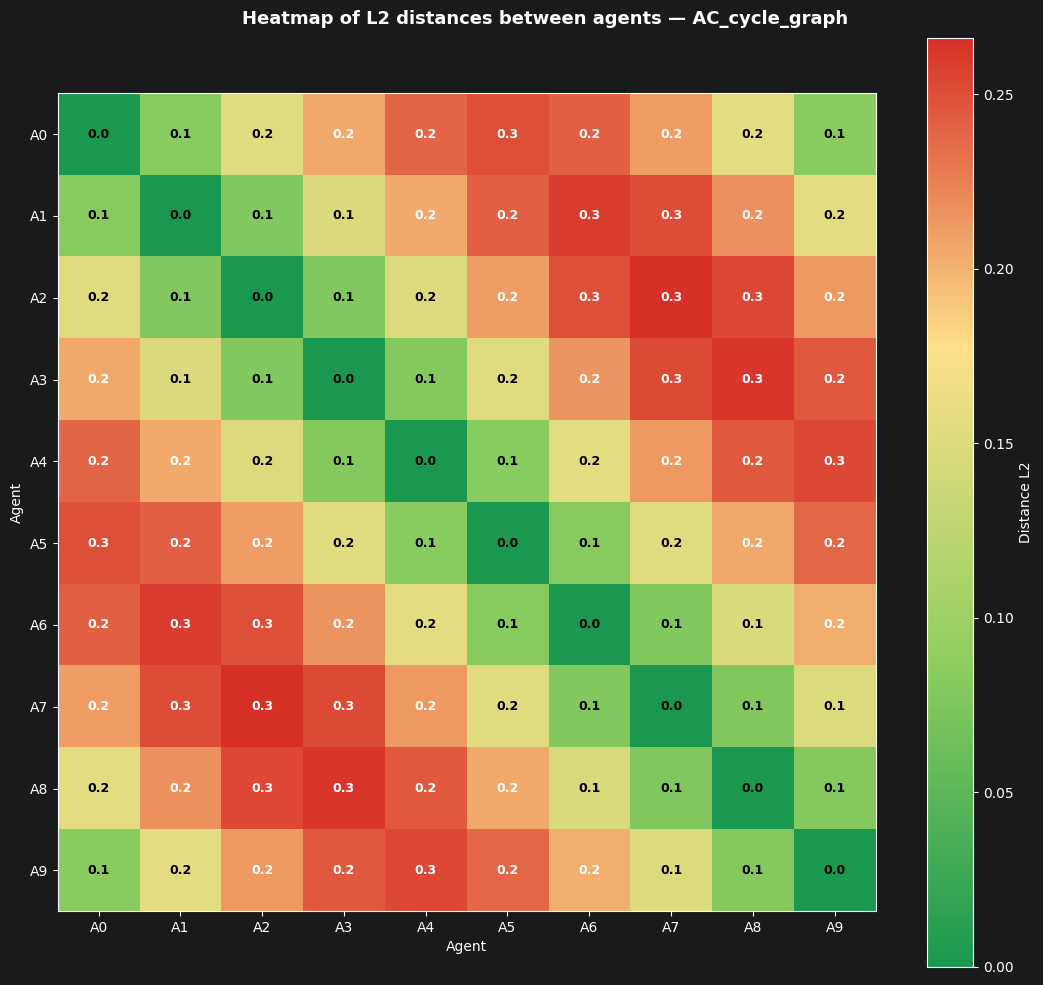

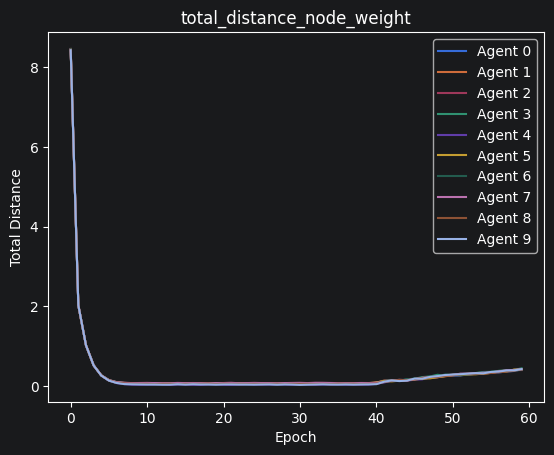

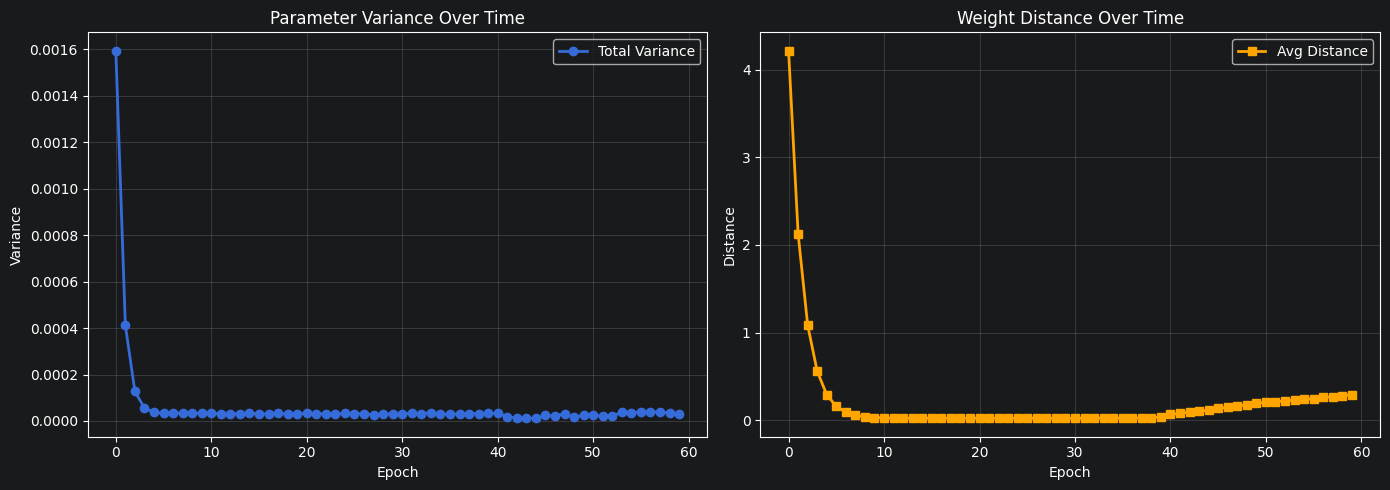


── AC_star_graph ──

═══════════════════════════════════════════════════════
  RunResult : AC_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 55.11%
  Val Loss  finale : 1.2288
  Temps total      : 1979.35s
  Temps moyen/ép.  : 32.99s
  Époque la + rapide : ép.6 (32.35s)
  Époque la + lente  : ép.35 (33.67s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_star_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 1277.284 MB
    Total messages    : 5,400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 165.48 ms
    Synchro totale    : 9929.1 ms
─────────────────────────────────────────────

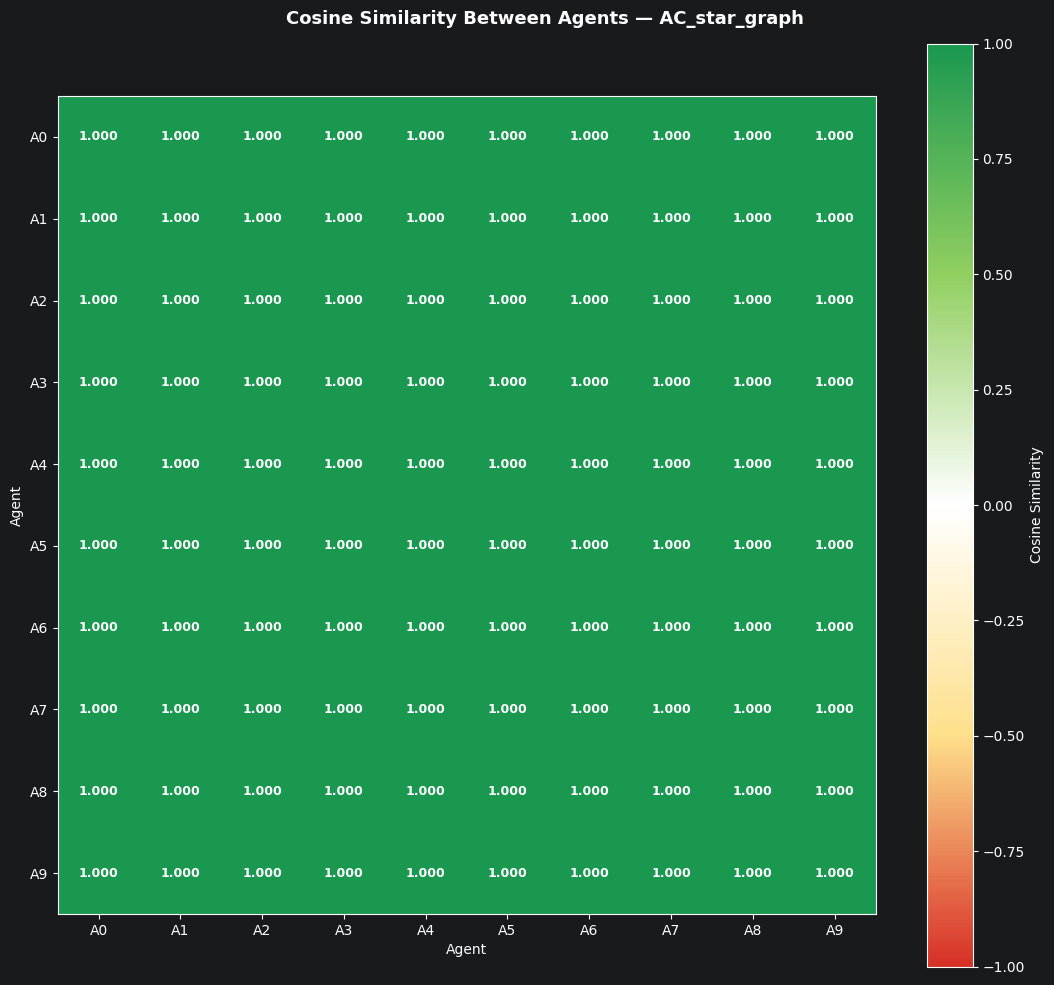

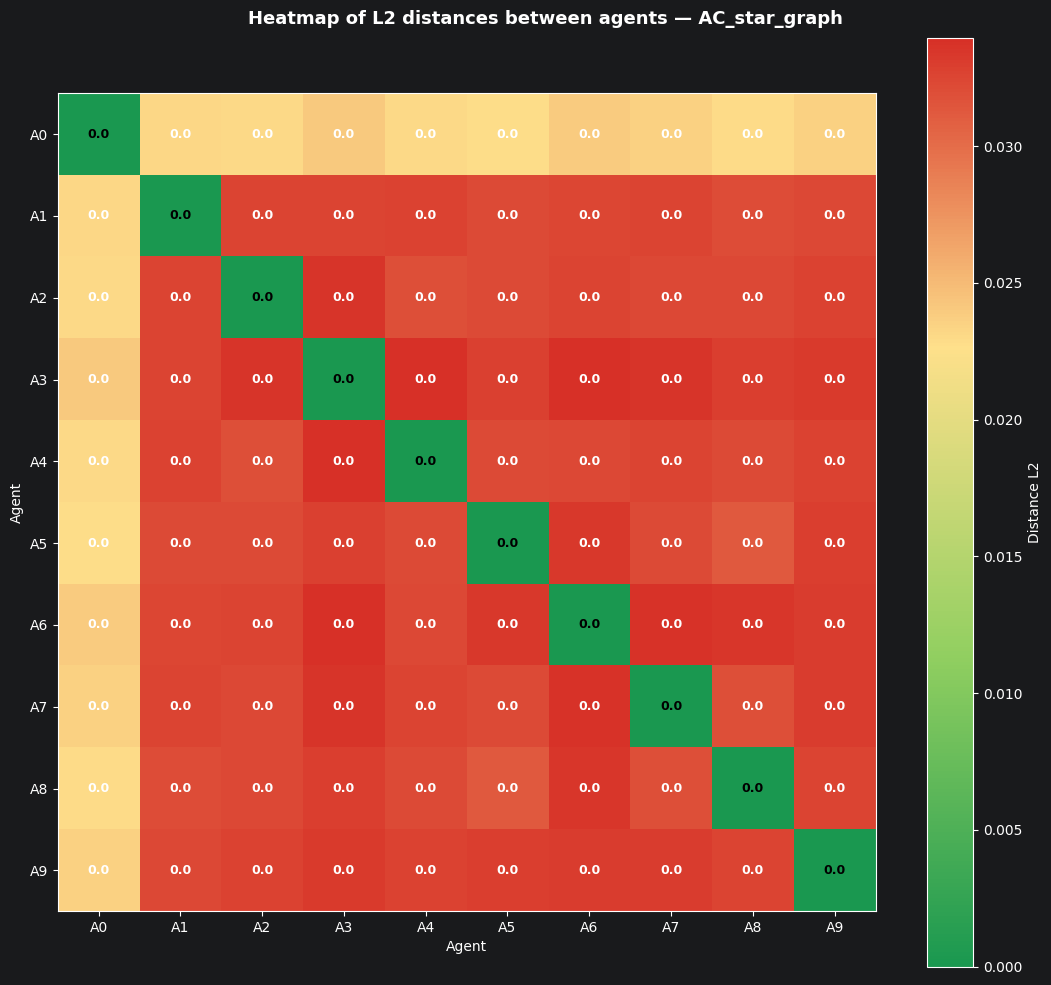

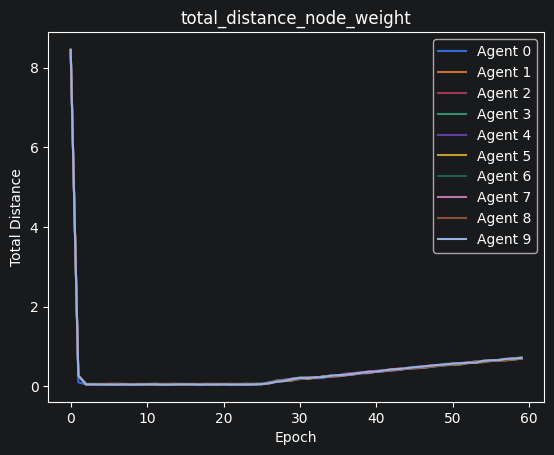

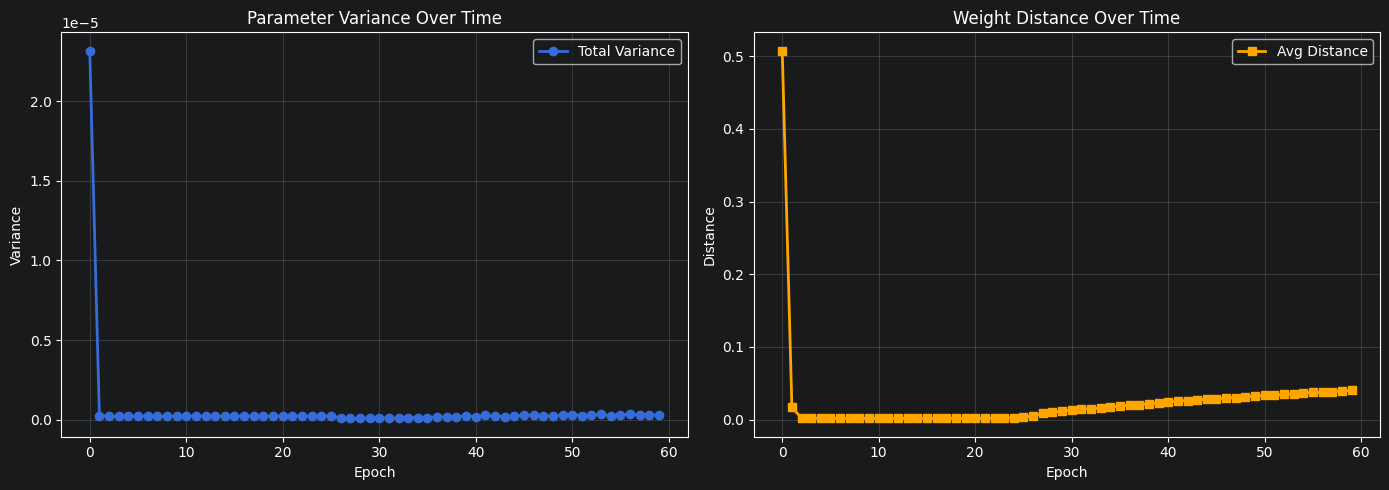


── AC_random_graph ──

═══════════════════════════════════════════════════════
  RunResult : AC_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 12.00%
  Val Loss  finale : 2.3025
  Temps total      : 1991.64s
  Temps moyen/ép.  : 33.19s
  Époque la + rapide : ép.6 (32.50s)
  Époque la + lente  : ép.16 (38.76s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — AC_random_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 2772.180 MB
    Total messages    : 11,720
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 182.51 ms
    Synchro totale    : 10950.6 ms
─────────────────────────────────────

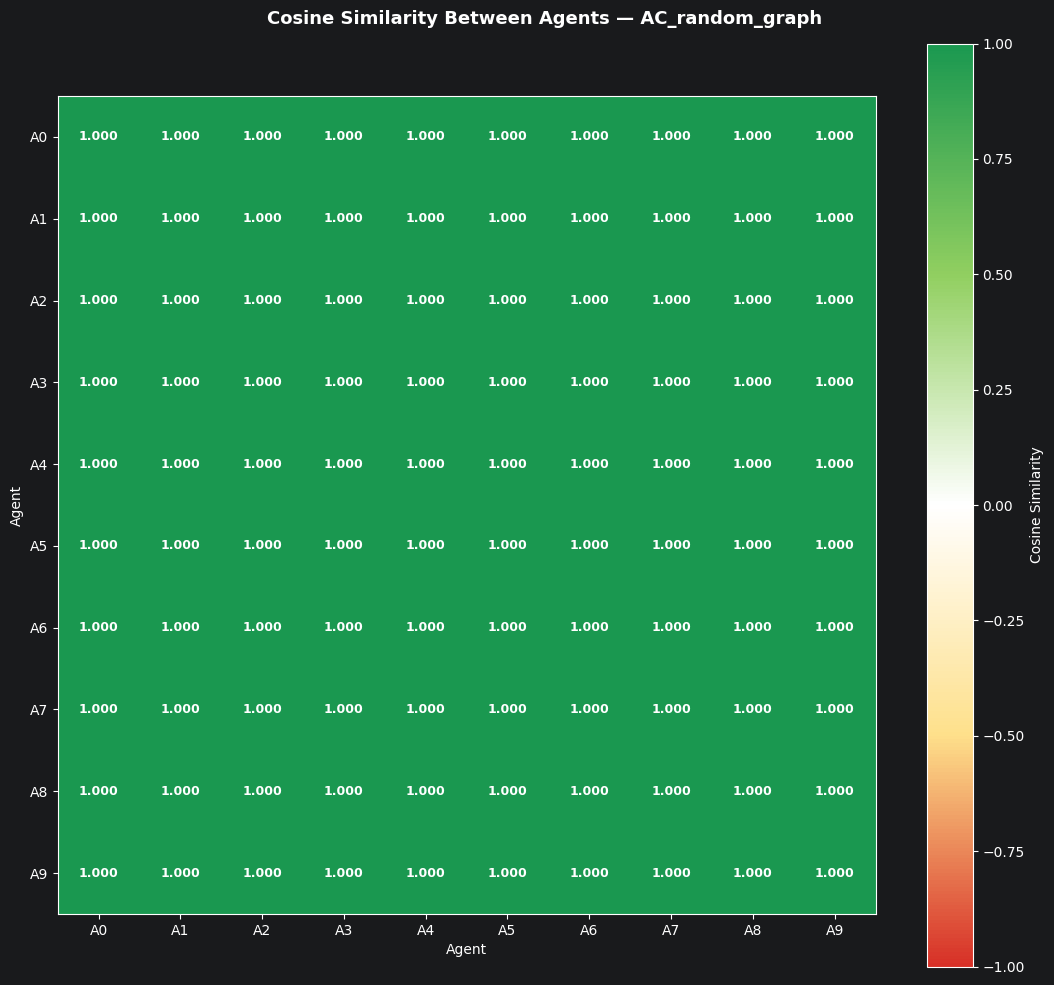

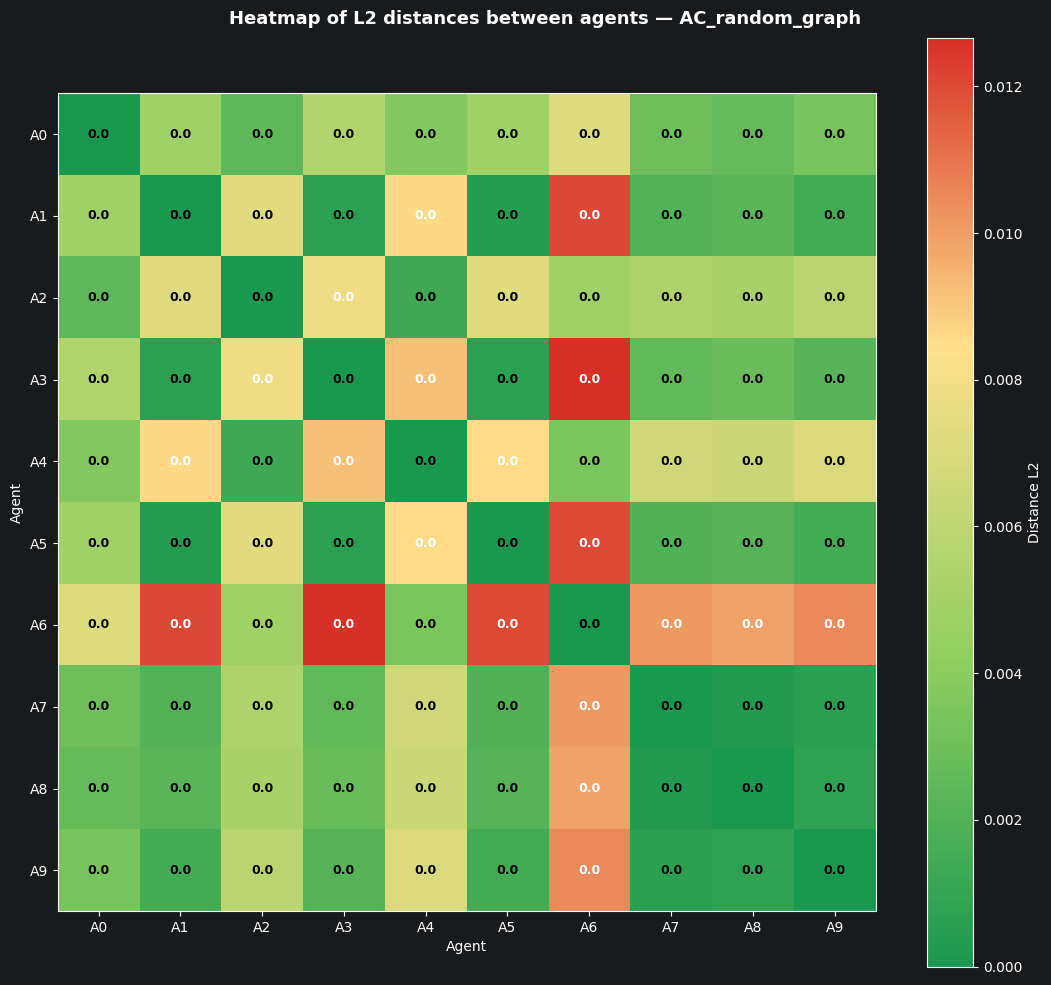

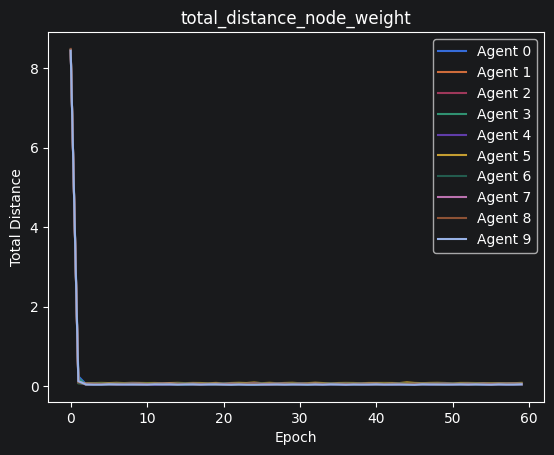

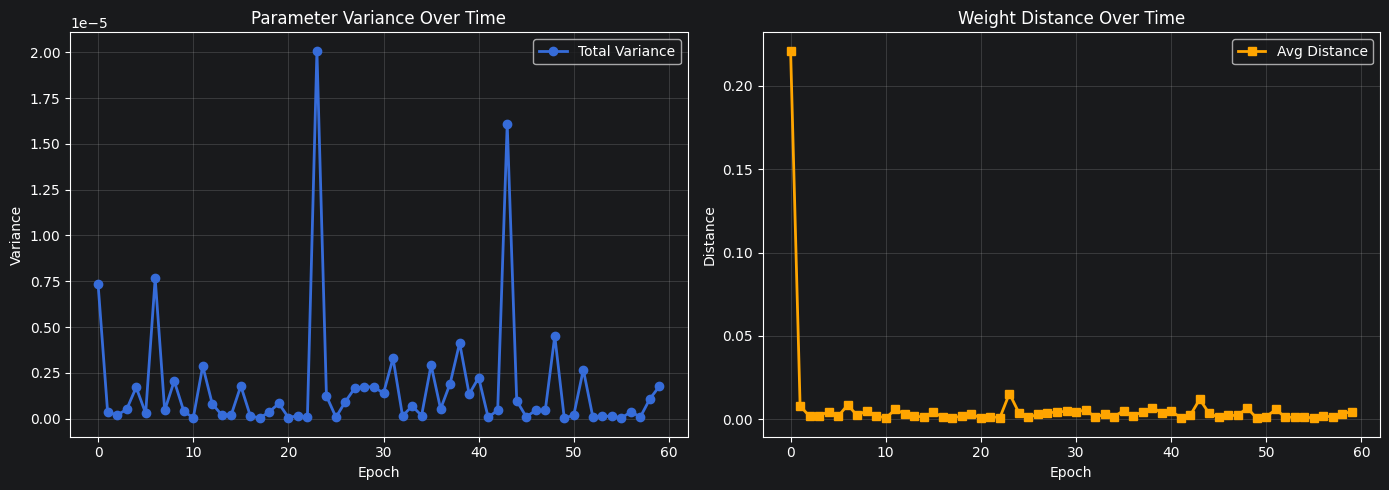

In [20]:
for result in results:
    print(f"\n── {result.method_name} ──")
    print(result)
    result.comm_cost.summary()

    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [21]:
def Sequential_AC_fully_connected_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_cycle_graph(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_star_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


def Sequential_AC_random_graph(agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    Sequential_AC(
        agent_list,
        graph,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "Sequential_AC_connected_graph":
        Sequential_AC_fully_connected_graph,

    "Sequential_AC_cycle_graph":
        Sequential_AC_cycle_graph,

    "Sequential_AC_star_graph":
        Sequential_AC_star_graph,

    "Sequential_AC_random_graph":
        Sequential_AC_random_graph,
}

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=random_graph,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)



  RUN — méthode : Sequential_AC_connected_graph


C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


0
Train size: 50000, Splits: [5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555, 5555], Sum: 55550
  [Epoch 1/60] threads started …
Agent 3 start
Agent 1 start
Agent 0 start
Agent 9 start
Agent 7 start
Agent 8 start
Agent 4 start
Agent 2 start
Agent 5 start
Agent 6 start
Model3 - Acc:10.68 % - Loss:2.3030340723991394 %
Model1 - Acc:11.1 % - Loss:2.3028588647842407 %
Model9 - Acc:10.26 % - Loss:2.3035481357574463 %
Model7 - Acc:13.08 % - Loss:2.293669721126556 %
Model4 - Acc:10.7 % - Loss:2.3007182841300966 %
Model0 - Acc:9.8 % - Loss:2.3036870093345643 %
Model2 - Acc:11.32 % - Loss:2.3015098900794984 %
Model5 - Acc:9.86 % - Loss:2.3030976004600525 %
Model8 - Acc:11.18 % - Loss:2.3011454858779907 %
Model6 - Acc:10.78 % - Loss:2.301856906414032 %
[DEBUG] set_epoch_messages called → 90 messages
[DEBUG] _resolve_n_messages → _epoch_n_messages = 90
[DEBUG] _record epoch=0 → n_messages=90
  [Epoch 1/60] ✓  time=32.92s  cumulative=32.92s
  [Epoch 2/60] threads started …
Agent 5 start
Agent

In [22]:
comparator.rank()


══════════════════════════════════════════════════════════════════════
  CLASSEMENT DES MÉTHODES PAR EFFICACITÉ (accuracy / MB)
──────────────────────────────────────────────────────────────────────
  Rang  Méthode                   Total MB     Synchro moy    Efficacité
──────────────────────────────────────────────────────────────────────
  1     Sequential_AC_connected_graph 1277.284     69.85          N/A
  2     Sequential_AC_cycle_graph 283.841      15.96          N/A
  3     Sequential_AC_star_graph  255.457      14.08          N/A
  4     Sequential_AC_random_graph 565.317      30.44          N/A
══════════════════════════════════════════════════════════════════════



[('Sequential_AC_connected_graph', 1277.2842407226562, 69.85154332748304, 0.0),
 ('Sequential_AC_cycle_graph', 283.8409423828125, 15.957629998835424, 0.0),
 ('Sequential_AC_star_graph', 255.45684814453125, 14.080528363895914, 0.0),
 ('Sequential_AC_random_graph', 565.3165435791016, 30.438738347341616, 0.0)]

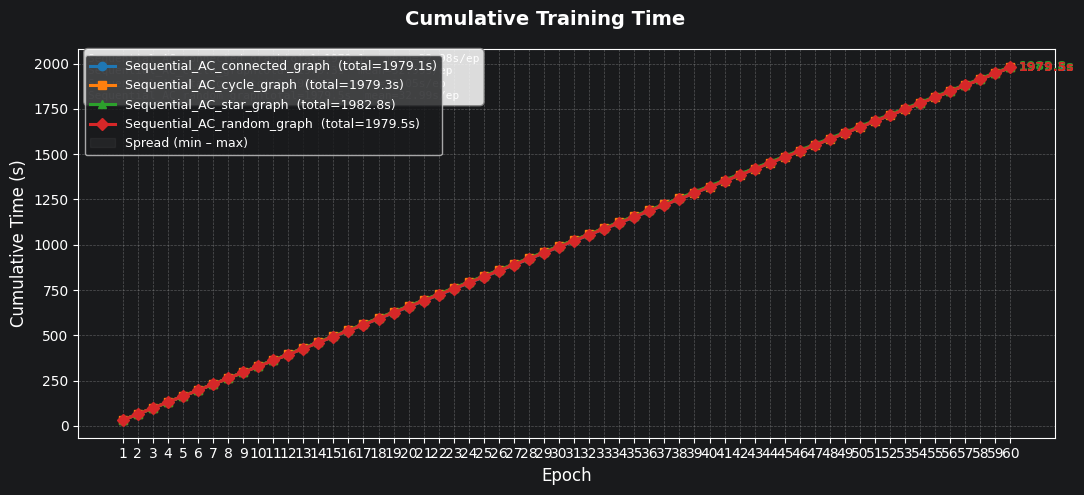

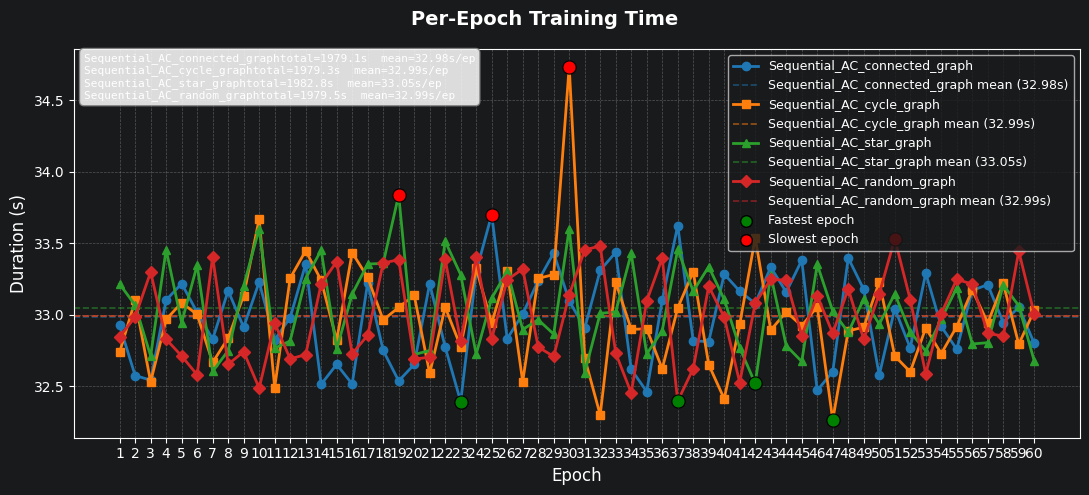

In [23]:
plot_cumulative_times(results)
plot_epoch_times(results)

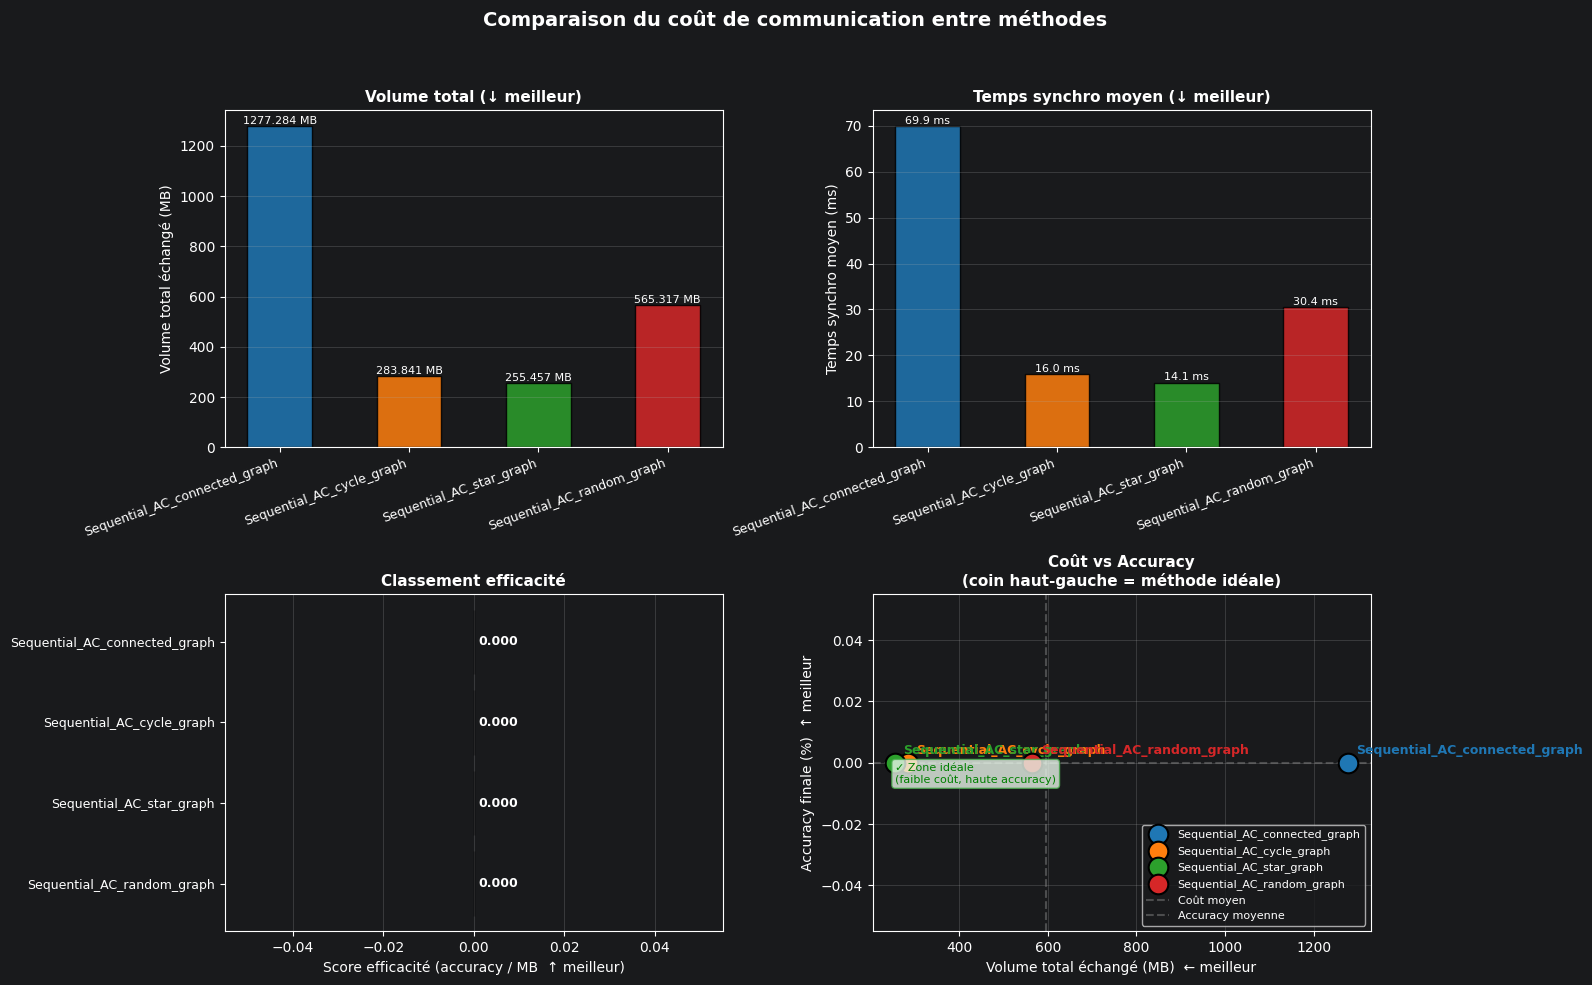

In [24]:
comparator.plot_comparison()

In [25]:
print_benchmark_summary(results)


Méthode                          Val Loss    Val Acc  Train Acc
Sequential_AC_connected_graph      1.6898     53.20%     50.50%
Sequential_AC_cycle_graph          1.1399     60.50%     62.68%
Sequential_AC_star_graph           1.5531     56.73%     52.26%
Sequential_AC_random_graph         1.1289     60.11%     59.78%


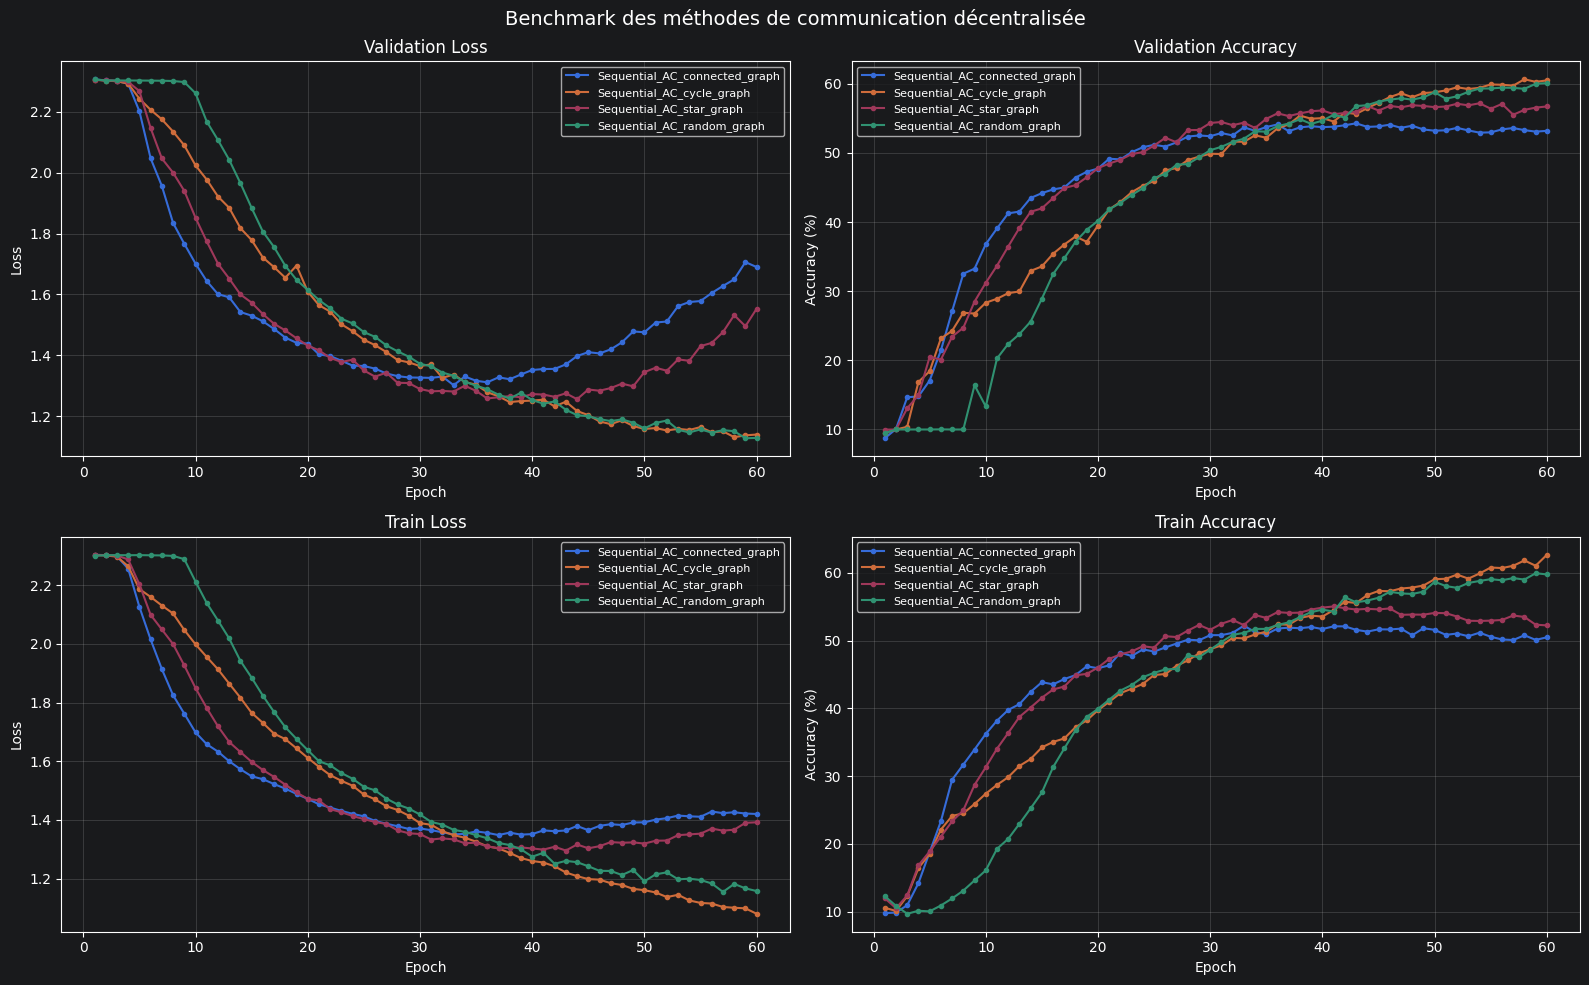

In [26]:
plot_all_benchmark_metrics(results)

In [46]:
from matplotlib import pyplot as plt


def plot_average_distance(results):

    plt.figure(figsize=(8, 5))

    for result in results:

        # Toutes les distances de tous les agents
        agent_distances = [
            agent.total_distance_list
            for agent in result.agent_list
        ]

        # Moyenne des distances à chaque époque
        avg_dist = np.mean(agent_distances, axis=0)

        epochs = range(1, len(avg_dist) + 1)

        plt.plot(
            epochs,
            avg_dist,
            label=result.method_name
        )

    plt.xlabel("Epoch")
    plt.ylabel("Average Weight Distance")
    plt.title("Consensus Convergence")
    plt.legend()
    plt.grid(True)
    plt.show()

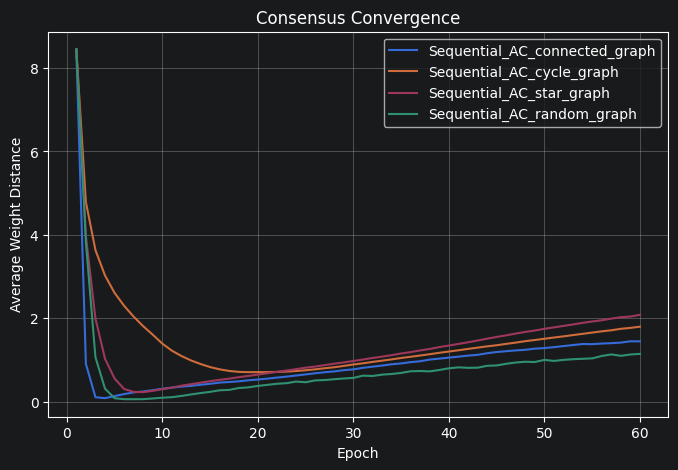

In [48]:
plot_average_distance(results)

In [44]:

plot_average_distance(results)


ValueError: too many values to unpack (expected 2, got 10)

<Figure size 800x500 with 0 Axes>


── Sequential_AC_connected_graph ──

═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_connected_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 53.20%
  Val Loss  finale : 1.6898
  Temps total      : 1979.10s
  Temps moyen/ép.  : 32.98s
  Époque la + rapide : ép.23 (32.39s)
  Époque la + lente  : ép.25 (33.70s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_connected_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 1277.284 MB
    Total messages    : 5,400
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 69.85 ms
    Synchro totale    : 4191.1 

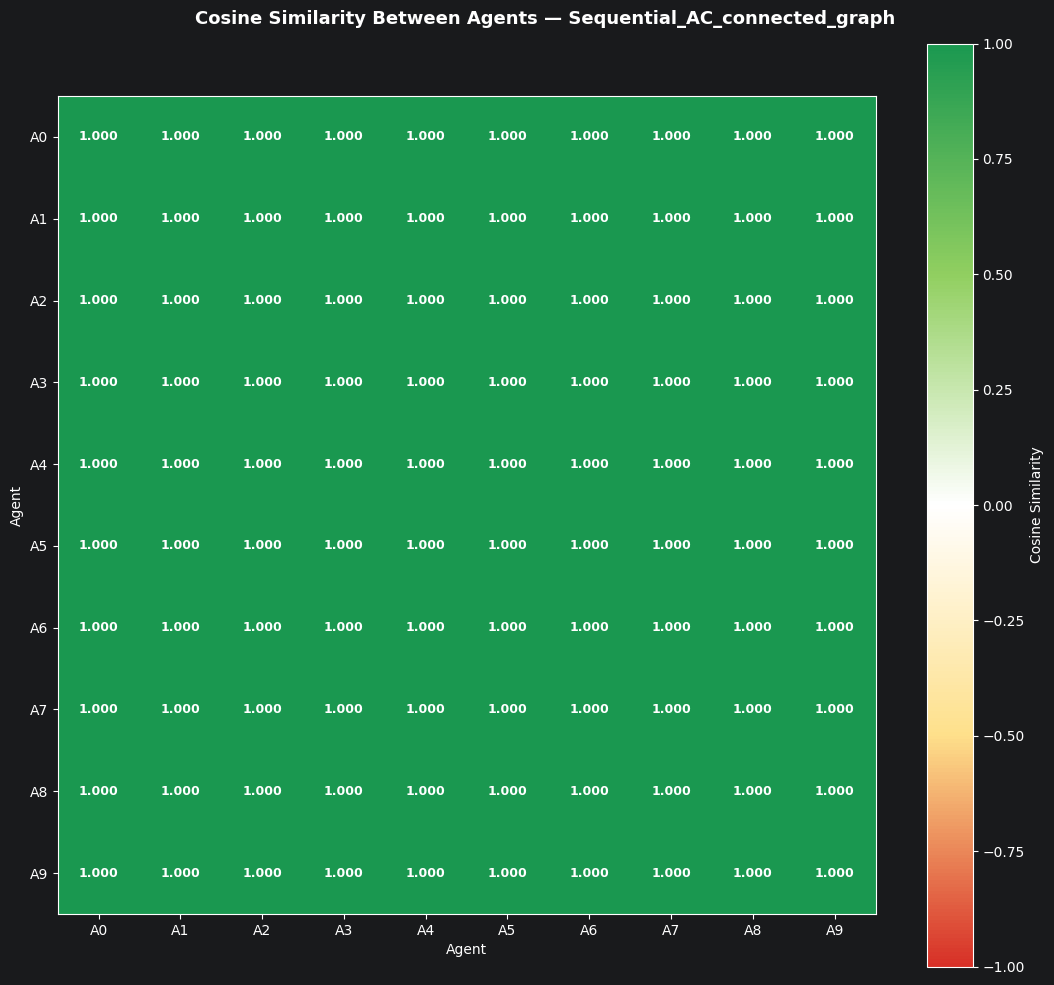

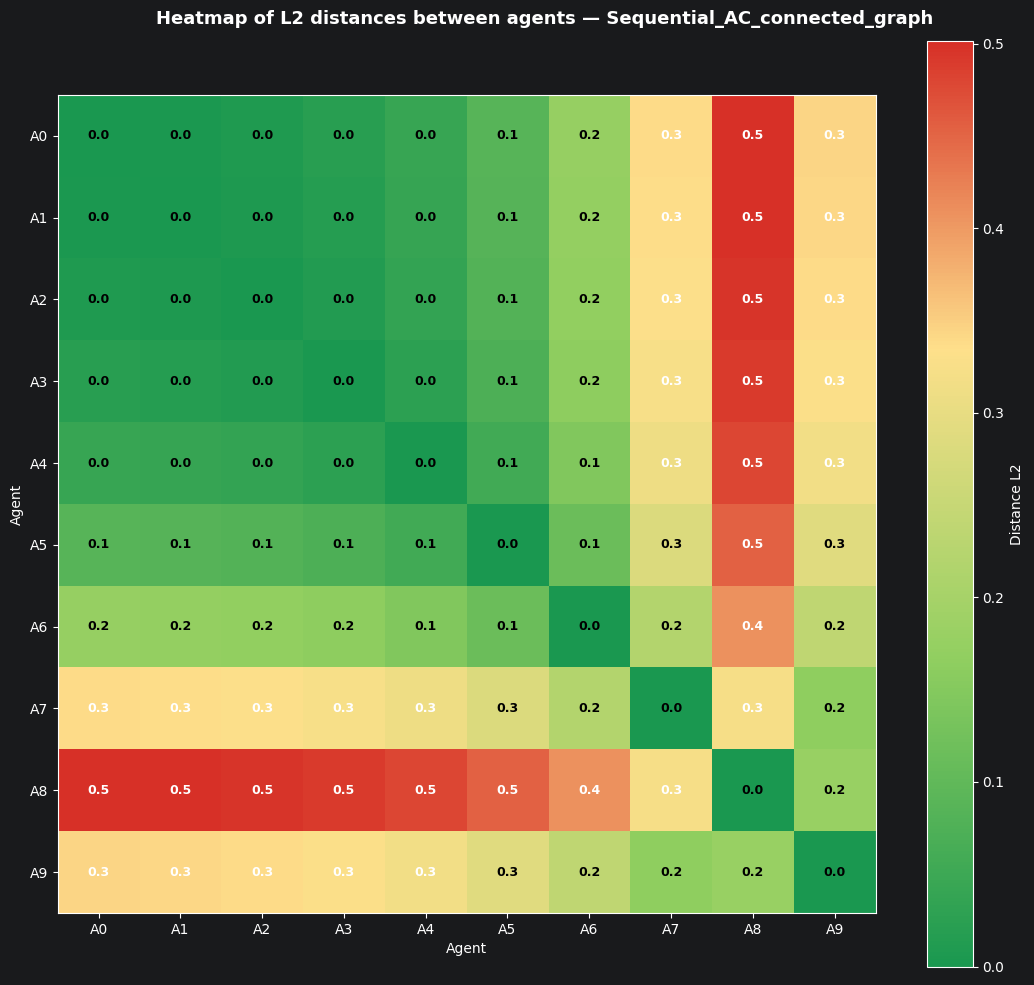

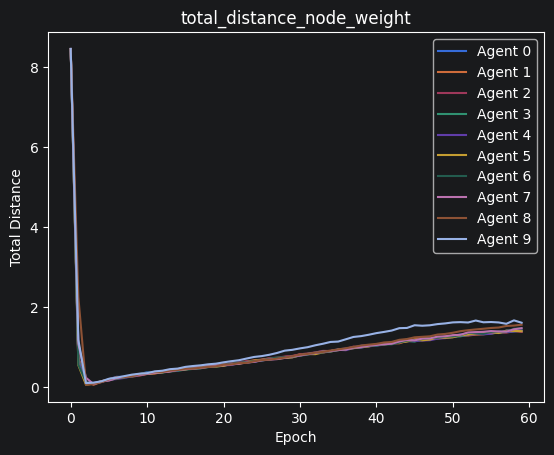

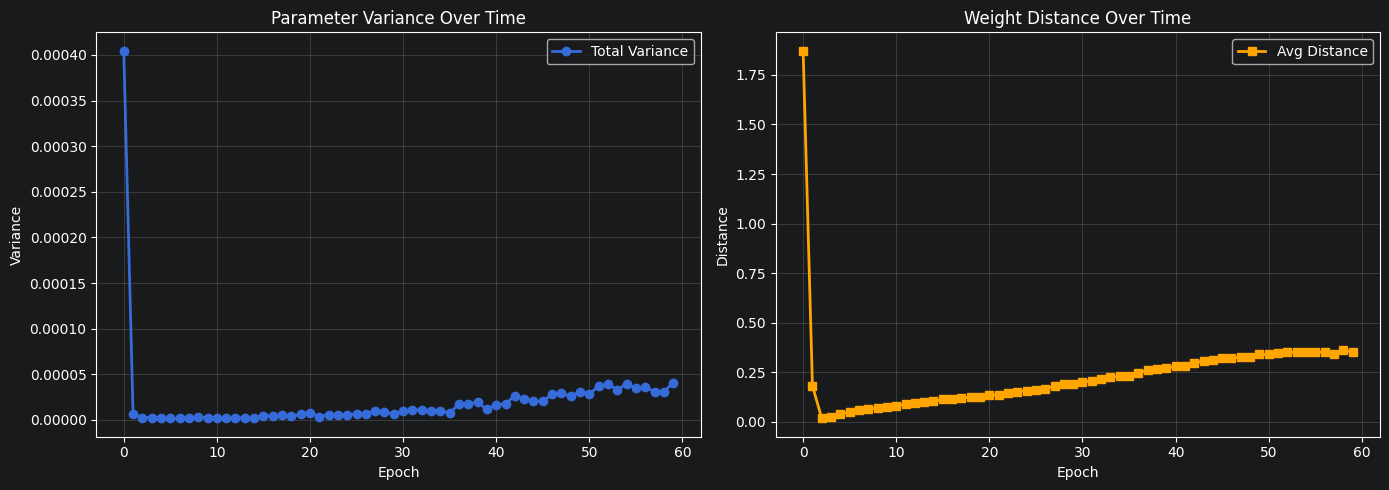


── Sequential_AC_cycle_graph ──

═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_cycle_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 60.50%
  Val Loss  finale : 1.1399
  Temps total      : 1979.28s
  Temps moyen/ép.  : 32.99s
  Époque la + rapide : ép.47 (32.26s)
  Époque la + lente  : ép.30 (34.73s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_cycle_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 283.841 MB
    Total messages    : 1,200
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 15.96 ms
    Synchro totale    : 957.5 ms
───────────

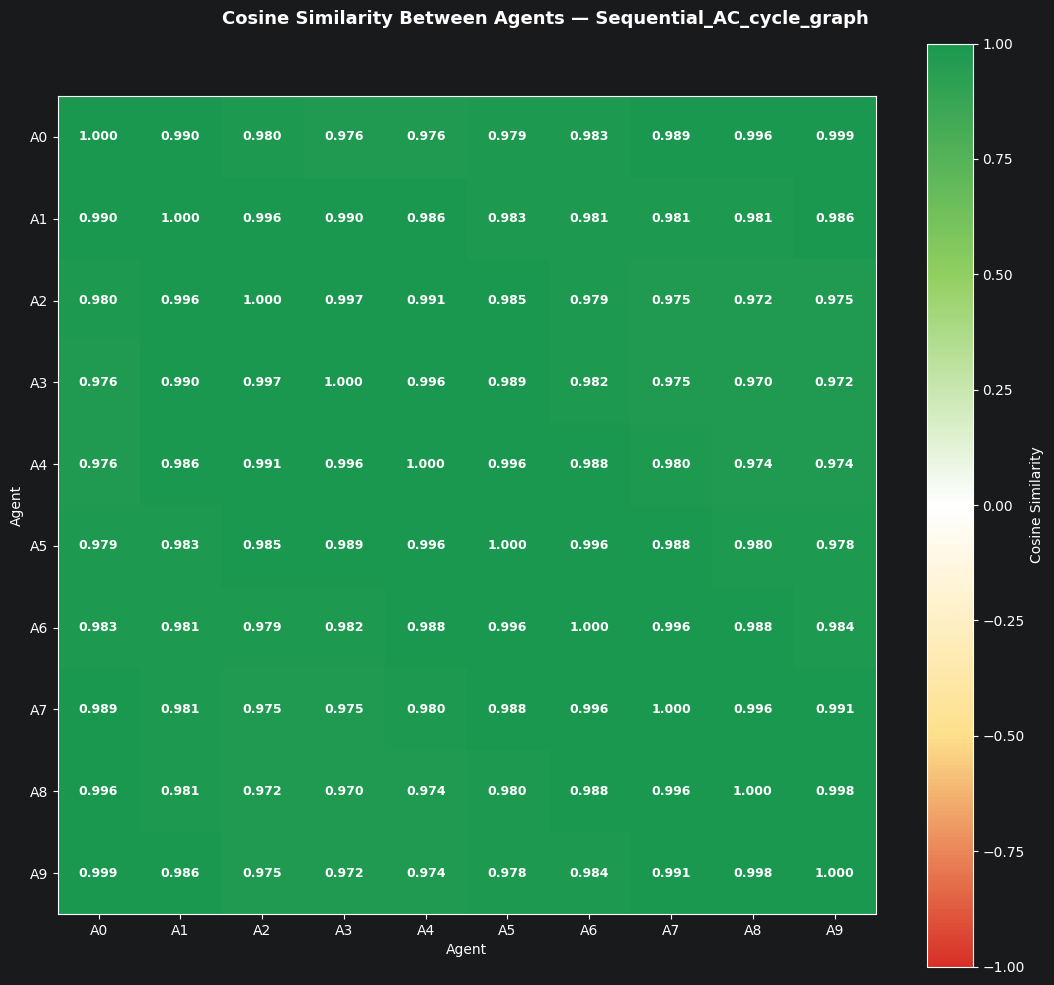

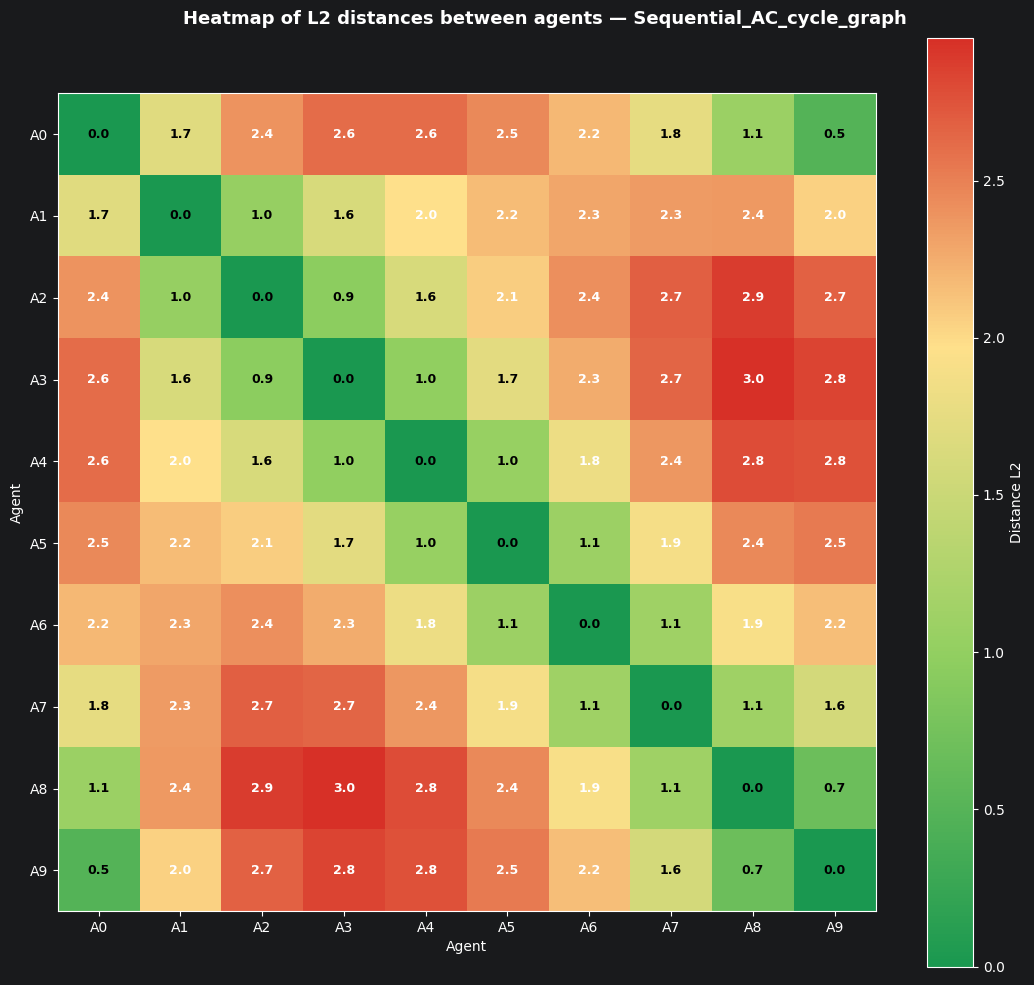

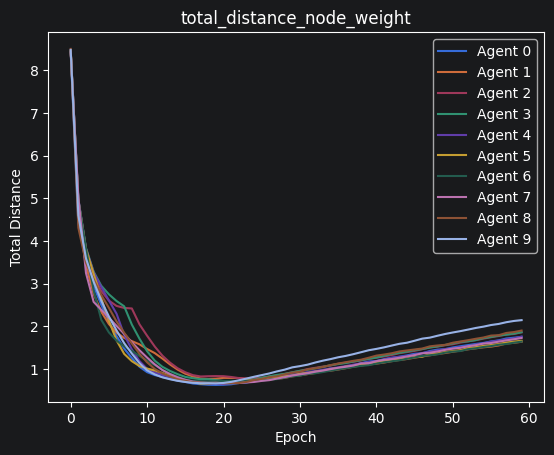

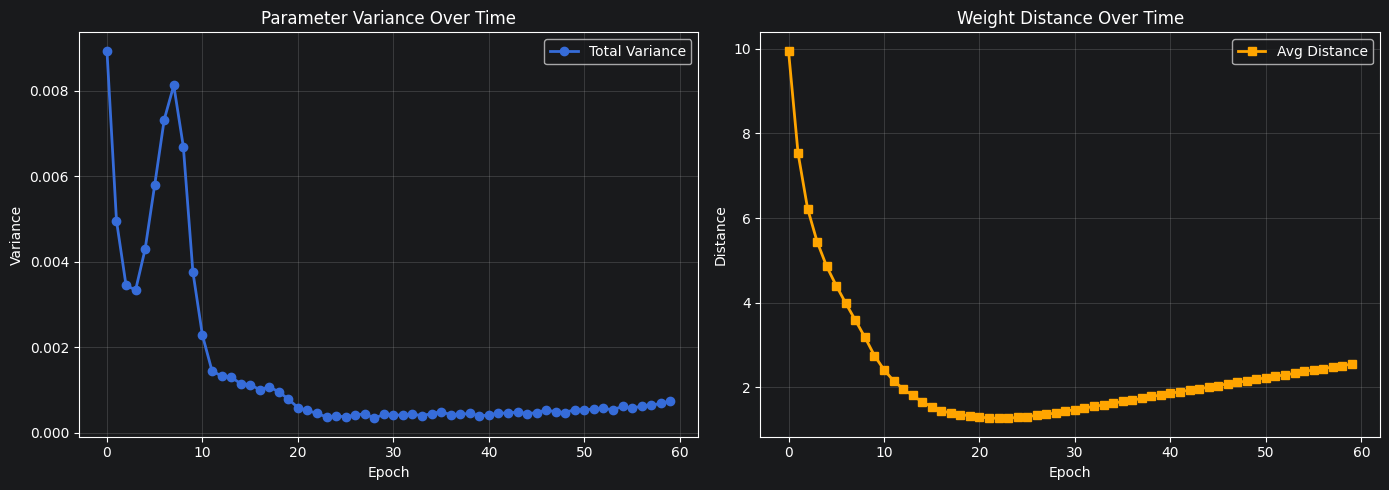


── Sequential_AC_star_graph ──

═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_star_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 56.73%
  Val Loss  finale : 1.5531
  Temps total      : 1982.83s
  Temps moyen/ép.  : 33.05s
  Époque la + rapide : ép.42 (32.52s)
  Époque la + lente  : ép.19 (33.84s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_star_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 255.457 MB
    Total messages    : 1,080
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 14.08 ms
    Synchro totale    : 844.8 ms
──────────────

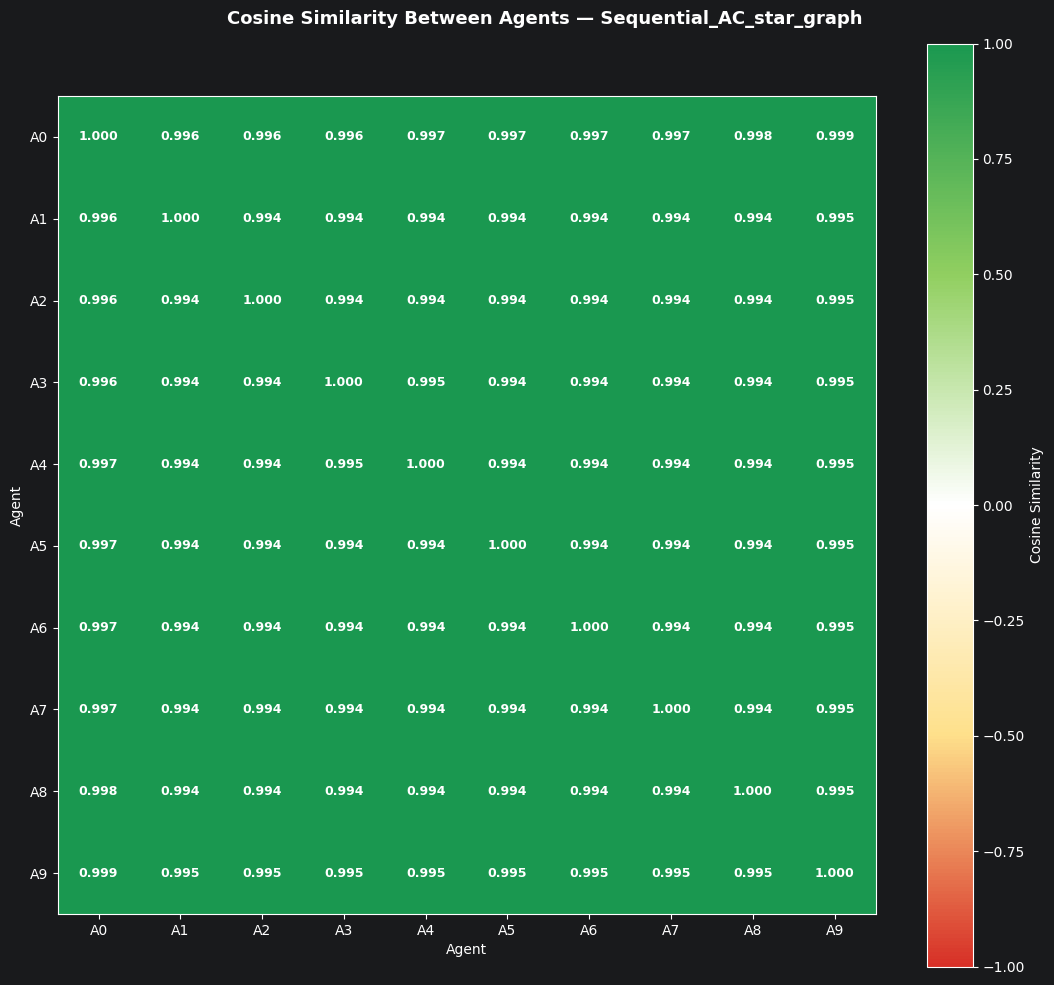

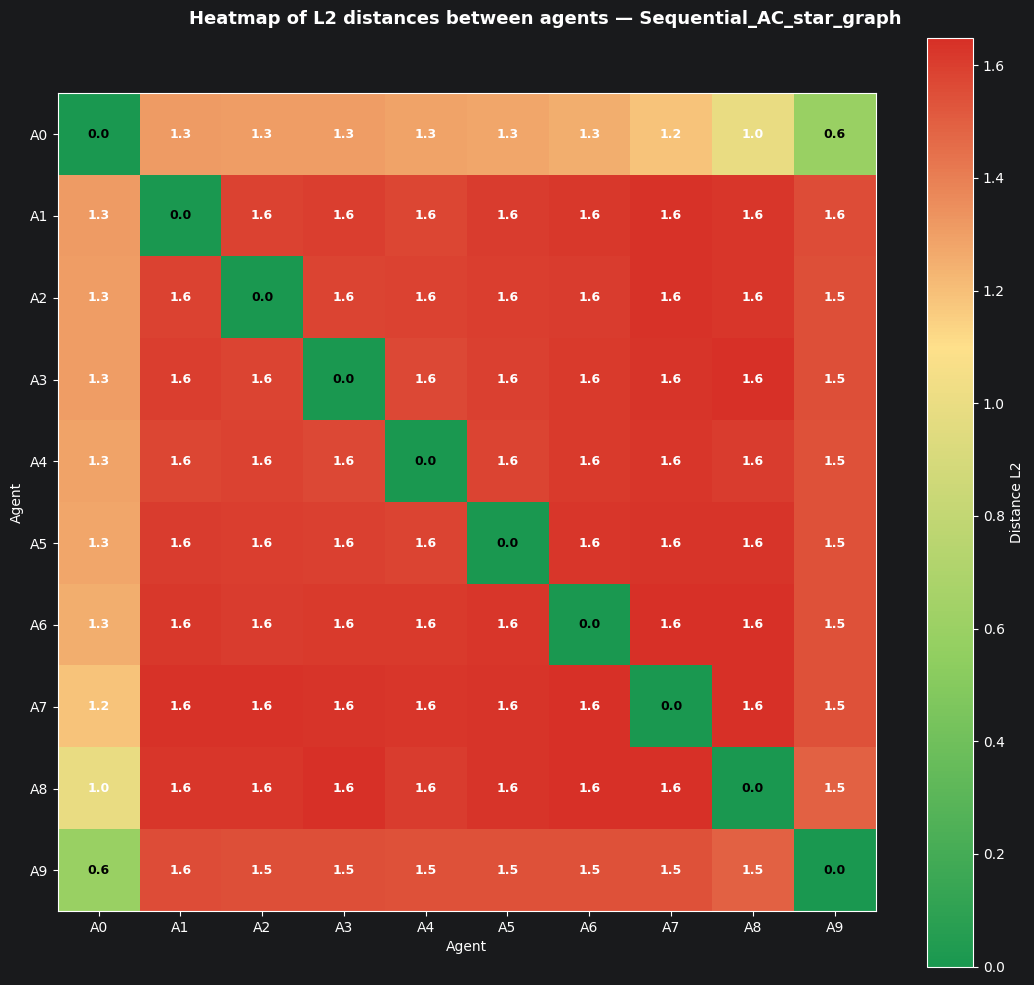

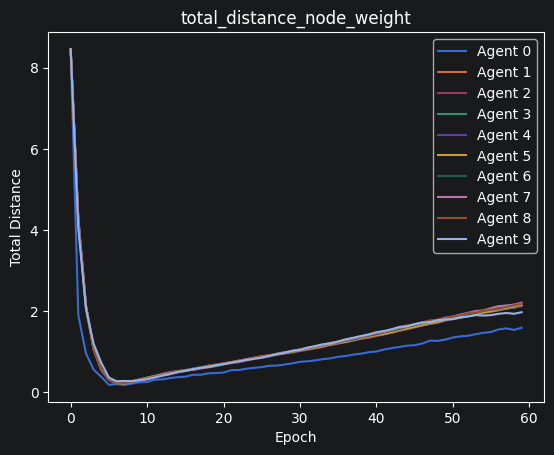

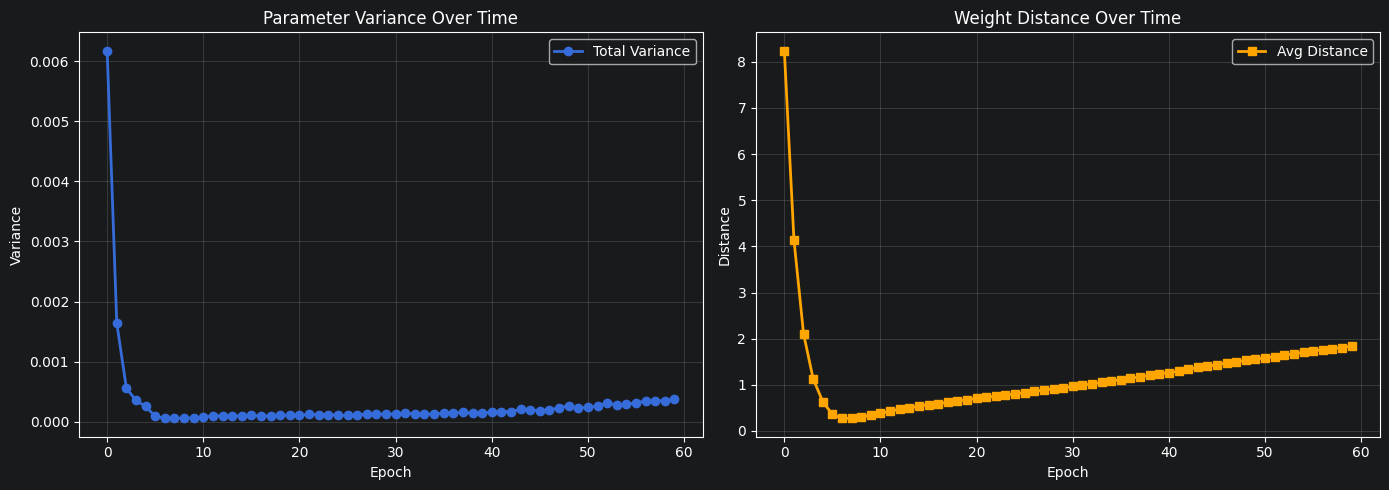


── Sequential_AC_random_graph ──

═══════════════════════════════════════════════════════
  RunResult : Sequential_AC_random_graph
───────────────────────────────────────────────────────
  Accuracy  finale : 60.11%
  Val Loss  finale : 1.1289
  Temps total      : 1979.52s
  Temps moyen/ép.  : 32.99s
  Époque la + rapide : ép.37 (32.39s)
  Époque la + lente  : ép.51 (33.53s)
═══════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  CommunicationCostMetric — Sequential_AC_random_graph
──────────────────────────────────────────────────────────
  Agents              : 10
  Paramètres/modèle   : 62,006
  Époques mesurées    : 60
──────────────────────────────────────────────────────────
  VOLUME
    Octets/message    : 242.2 KB
    Total échangé     : 565.317 MB
    Total messages    : 2,390
──────────────────────────────────────────────────────────
  TEMPS
    Synchro moy./ép.  : 30.44 ms
    Synchro totale    : 1826.3 ms
───────

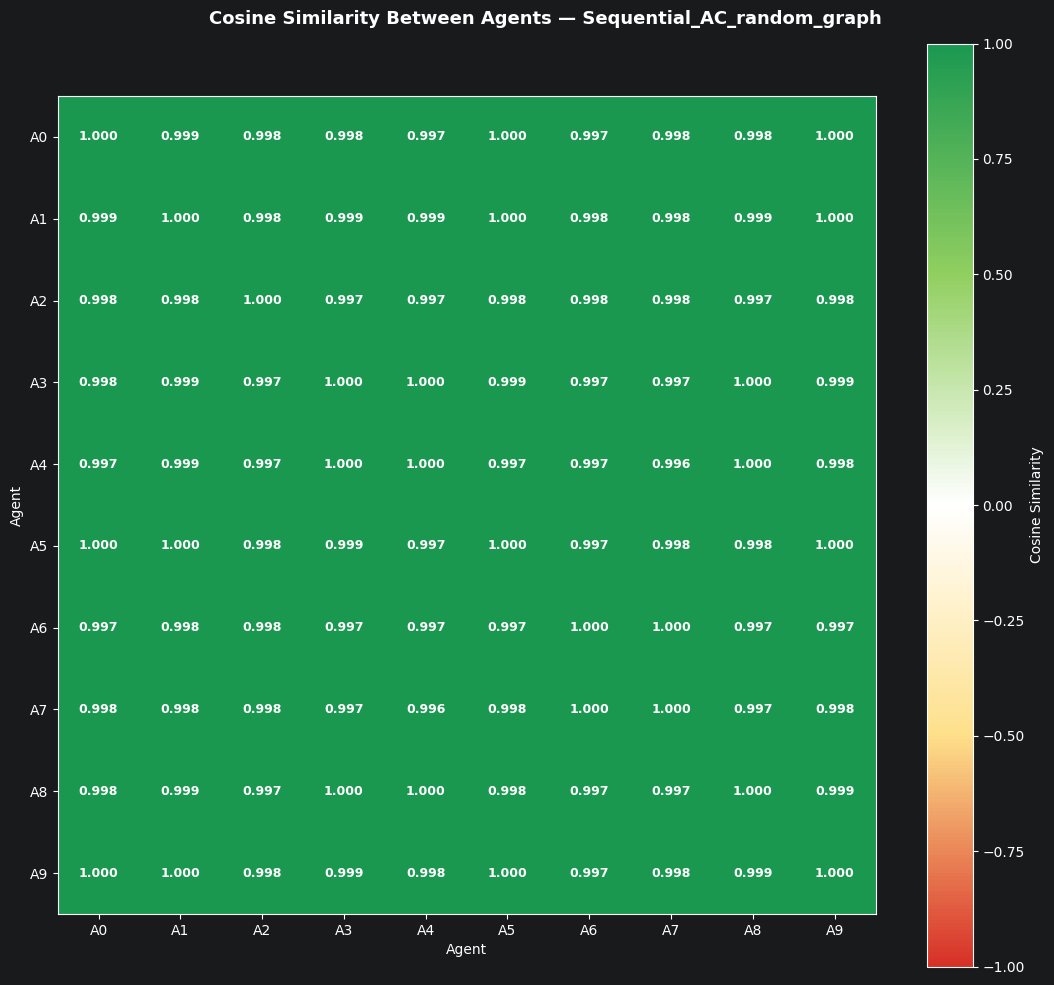

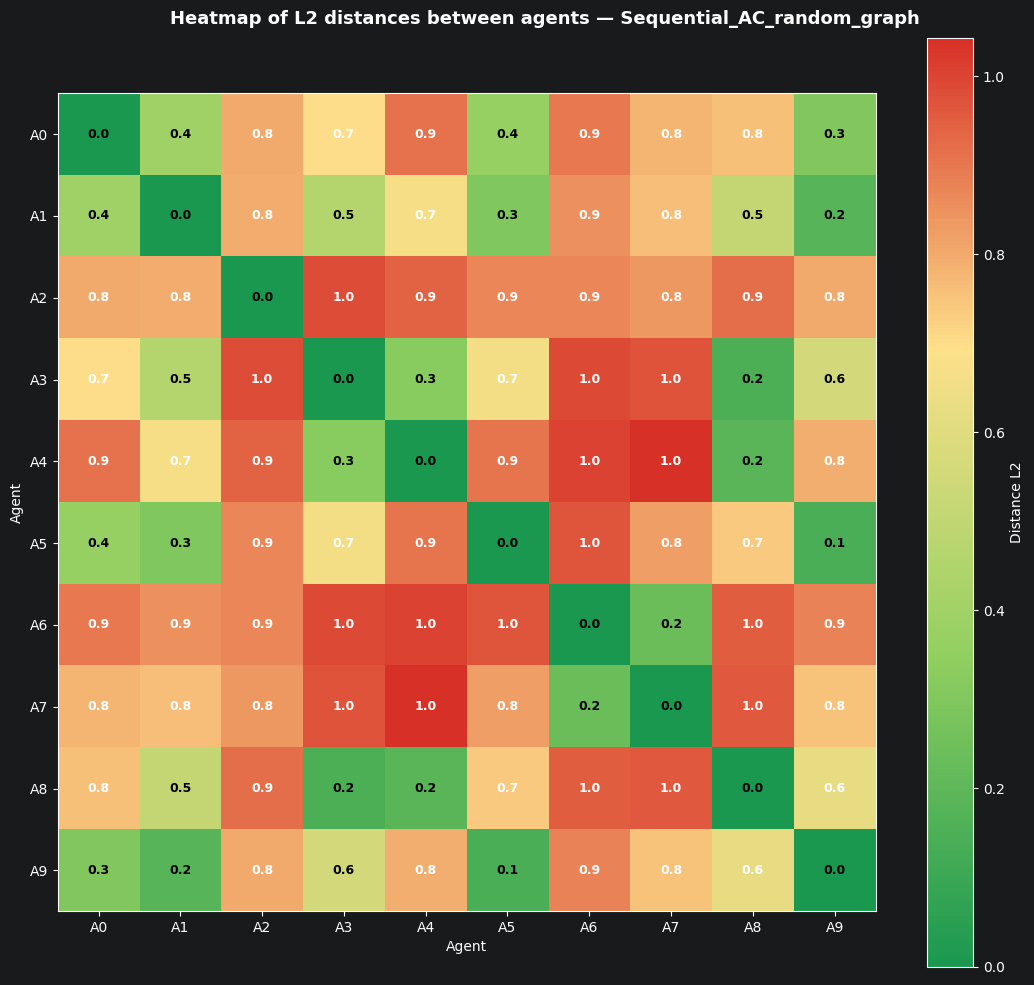

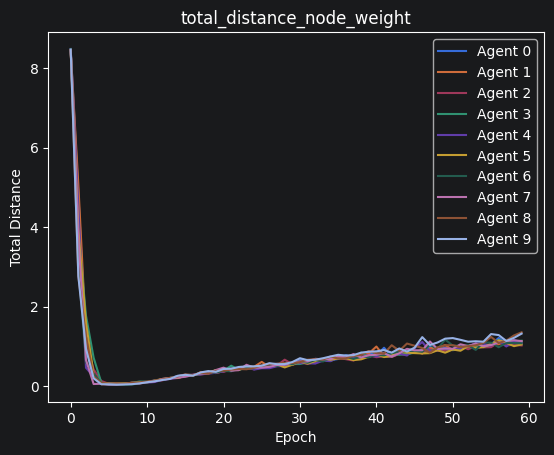

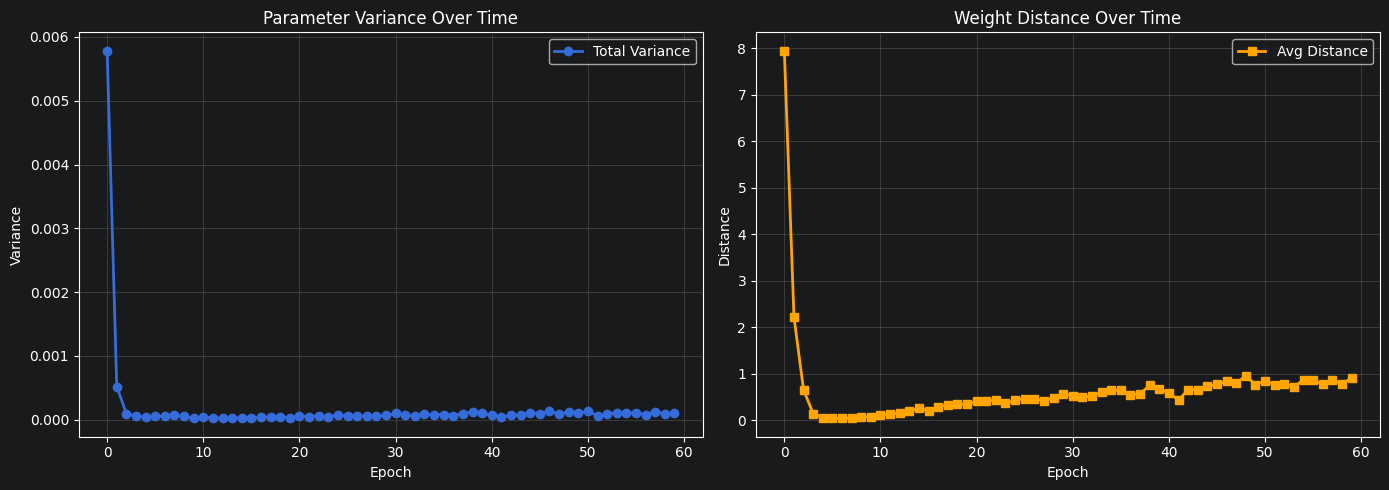

In [28]:
for result in results:
    print(f"\n── {result.method_name} ──")
    print(result)
    result.comm_cost.summary()

    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()

In [ ]:
def Average_consensus_fully_connected_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.fully_connected_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_cycle_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.cycle_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_star_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.star_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


def Average_consensus_random_graph_k(
        agent_list, graph, k, epoch, num_epochs, comm_cost=None):

    graph = NetworkTopology.random_graph(len(agent_list))

    Average_consensus_algorithm_K(
        agent_list,
        graph,
        K=k,
        comm_cost=comm_cost
    )


# ──────────────────────────────────────────────────────────────
# Dictionnaire des méthodes à comparer
# ──────────────────────────────────────────────────────────────

COMMUNICATION_METHODS = {

    "AC_fully_connected_graph":
        Average_consensus_fully_connected_graph_k,

    "AC_cycle_graph":
        Average_consensus_cycle_graph_k,

    "AC_star_graph":
        Average_consensus_star_graph_k,

    "AC_random_graph":
        Average_consensus_random_graph_k,
}


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

agent_list = generate_agent(BATCH_SIZE, N_AGENT, DEVICE)

results, comparator = benchmark_sequential(
    communication_methods=COMMUNICATION_METHODS,
    num_epochs=NUM_EPOCHES,
    graph=none,
    k=k,
    BATCH_SIZE=BATCH_SIZE,
    N_AGENT=N_AGENT,
    DEVICE=DEVICE,
)

print_benchmark_summary(results)
comparator.rank()
plot_all_benchmark_metrics(results)
plot_average_distance(results)
plot_cumulative_times(results)
plot_epoch_times(results)

for result in results:
    print(result)
    plot_cosine_similarity(result)
    plot_distance_heatmap(result.agent_list, result.method_name)
    plot_all_agent_node_weight_metric(result.agent_list)

    result.metrics.plot_history()
    result.comm_cost.summary()